# Frequência e Tipos de Atividade Física entre Universitários da UFSCar

# Tópicos:

1. Introdução
2. Importação das bibliotecas
3. Carregamento dos dados
4. Limpeza e tratamento dos dados
5. Análise estatística
6. Construção dos gráficos
7. Conclusão

# 1. Introdução

## Probabilidade e Estatística

### Integrantes:
- Kailayni Rodrigues Janez
- Gustavo Henrique Garcia Ribeiro
- Letícia Paulino Guerra
- Pedro Milani Biazotto
- Tatiane Maia de Oilveira

---

Este trabalho tem como objetivo analisar os hábitos de prática de atividade física entre estudantes universitários da UFSCar, utilizando técnicas de Estatística Descritiva.

**Objetivo da Pesquisa**

A pesquisa busca identificar:

- A proporção de estudantes que praticam atividade física;
- Os tipos de atividade física mais comuns;
- A frequência semanal das atividades;
- Os principais motivos para prática e não prática;
- Possíveis padrões relacionados ao perfil dos estudantes.

# 2. Importar bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# estilo
sns.set_theme(style="whitegrid")

# tamanho padrão
plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

#3. Carregamento da Base de Dados

Os dados foram coletados por meio de um formulário online disponibilizado aos estudantes.

Nesta etapa, realizamos a importação da planilha contendo as respostas.

In [ ]:
from google.colab import files

uploaded = files.upload()

df = pd.read_csv(next(iter(uploaded)))

df.head()

Saving Frequência e Tipos de Atividade Física entre Universitários do Curso  (respostas) - Respostas ao formulário 1.csv to Frequência e Tipos de Atividade Física entre Universitários do Curso  (respostas) - Respostas ao formulário 1 (1).csv


,Carimbo de data/hora,Você concorda em participar desta pesquisa e autoriza o uso das suas respostas de forma anônima exclusivamente para fins acadêmicos?,Qual é a sua faixa etária?,Como você se identifica em relação ao gênero?,Em que período do curso você está?,Qual é o seu curso?,Você pratica alguma atividade física regularmente?,Quantas atividades físicas diferentes você pratica regularmente?,Qual o tipo principal de atividade física que você pratica?,Quantos dias por semana você pratica atividade física?,"Em média, quantas horas por semana você dedica à atividade física?","Quanto tempo você leva, em média, para se deslocar até o local de prática (em minutos)?",Qual é o principal motivo para você praticar atividade física?,"Caso não pratique atividade física, qual o principal motivo?"
0,12/05/2026 14:40:36,"Sim, concordo em participar",27 anos ou mais,Mulher,8º ou mais,Química,Não,NaN,NaN,NaN,NaN,NaN,NaN,Motivos de saúde
1,15/05/2026 15:04:59,"Sim, concordo em participar",24-26 anos,Mulher,7º,Biotecnologia,Sim,2,Corrida/Caminhada,5.0,1-2 horas,Faço em casa,"Saúde, Estética",NaN
2,15/05/2026 15:20:37,"Sim, concordo em participar",24-26 anos,Homem,8º ou mais,Engenharia Civil,Sim,3,"Musculação, Corrida/Caminhada, Esporte Coletiv...",5.0,7-8 horas,10,"Saúde, Estética, Lazer, Desempenho Esportivo",NaN
3,15/05/2026 15:25:55,"Sim, concordo em participar",24-26 anos,Homem,1º,Engenharia de controle e automação,Sim,1,"Esporte Coletivos(futebol, Voleibol, basquete,...",1.0,1-2 horas,20 minutos,Lazer,NaN
4,15/05/2026 19:51:57,"Sim, concordo em participar",27 anos ou mais,Mulher,8º ou mais,Física,Sim,1,Musculação,5.0,9 horas ou mais,20,"Saúde, Estética",NaN


In [ ]:
# remover espaços extras dos nomes das colunas
df.columns = df.columns.str.strip()

#4. Limpeza e Tratamento dos Dados

Durante a coleta, algumas respostas foram preenchidas por pessoas externas à UFSCar ou apresentaram inconsistências na escrita dos cursos.

Assim, foi necessário realizar um processo de limpeza dos dados, incluindo:

- Padronização dos nomes dos cursos;
- Remoção de respostas inválidas;
- Exclusão de cursos não pertencentes à UFSCar -  campus São Carlos;
- Correção de diferenças de escrita.

**Código limpeza:**

In [ ]:
# ============================================================
# LIMPEZA DE DADOS
# Pesquisa: Atividade Física entre Universitários — UFSCar São Carlos
# ============================================================
# Pré-requisito: bibliotecas já importadas e df já carregado via:
#
#   import pandas as pd
#   import re
#   from collections import Counter
#   from itertools import combinations
#   from google.colab import files
#   uploaded = files.upload()
#   df = pd.read_csv(next(iter(uploaded)))
# ============================================================


# ── CÉLULA 1 — Visão geral do dado bruto ─────────────────────
print("Shape:", df.shape)
print("\nColunas:")
for col in df.columns:
    print(f"  • {col}")
print("\nPrimeiras linhas:")
df.head()


# ── CÉLULA 2 — CURSO: correções e filtro por campus São Carlos ─
coluna_curso = "Qual é o seu curso?"
df[coluna_curso] = df[coluna_curso].astype(str).str.strip()

correcoes_curso = {
    # Siglas
    "Enfi":                    "Enfermagem",
    "fln":                     "Licenciatura em Física",
    # Erros de digitação / acentuação
    "Fisica":                  "Física",
    "Fisica licenciatura":     "Licenciatura em Física",
    "Licenciatura em Fìsica":  "Licenciatura em Física",
    "Licenciatura emMatemática":"Licenciatura em Matemática",
    "Psicologia.":             "Psicologia",
    # Variações de capitalização
    "Ciência Sociais":         "Ciências Sociais",
    "Ciências sociais":        "Ciências Sociais",
    "ciências sociais":        "Ciências Sociais",
    "Ciência da computação":   "Ciência da Computação",
    "Educação especial":       "Educação Especial",
    "Educação física":         "Educação Física",
    "Engenharia de materiais": "Engenharia de Materiais",
    "Engenharia e Ciência de Materiais": "Engenharia de Materiais",
    "Gestão e análise ambiental": "Gestão e Análise Ambiental",
    "Imagem e som":            "Imagem e Som",
    "Letras inglês":           "Letras Inglês",
    "Letras português/inglês": "Letras Português/Inglês",
    "Terapia ocupacional":     "Terapia Ocupacional",
    "terapia ocupacional":     "Terapia Ocupacional",
}

cursos_validos = [
    "Biologia", "Biotecnologia", "Ciências Sociais", "Ciência da Computação",
    "Educação Especial", "Educação Física", "Enfermagem", "Engenharia Civil",
    "Engenharia Elétrica", "Engenharia Florestal", "Engenharia de Materiais",
    "Engenharia de Produção", "Física", "Gestão e Análise Ambiental",
    "Imagem e Som", "Letras Inglês", "Letras Português/Inglês",
    "Licenciatura em Física", "Licenciatura em Matemática", "Música",
    "Pedagogia", "Psicologia", "Química", "TILSP", "Terapia Ocupacional",
]

df[coluna_curso] = df[coluna_curso].replace(correcoes_curso)

# Auditoria: ver o que será descartado antes de descartar
descartados = df[~df[coluna_curso].isin(cursos_validos)]
print(f"⚠️  {len(descartados)} linha(s) descartada(s):")
print(descartados[coluna_curso].value_counts().to_string())

df_limpo = df[df[coluna_curso].isin(cursos_validos)].copy()
print(f"\nTotal original : {len(df)}")
print(f"Após limpeza   : {len(df_limpo)}")


# ── CÉLULA 3 — GÊNERO: agrupar Travesti em Outro ─────────────
col_genero = "Como você se identifica em relação ao gênero? "
df_limpo[col_genero] = df_limpo[col_genero].replace({"Travesti": "Outro"})
print(df_limpo[col_genero].value_counts())


# ── CÉLULA 4 — DESLOCAMENTO: texto livre → minutos numérico ──
col_desloc = (
    "Quanto tempo você leva, em média, para se deslocar "
    "até o local de prática (em minutos)?  "
)

#==== def extrair_minutos(valor):
  #====  if pd.isna(valor):
      #====  return None
   #==== v = str(valor).lower().strip()
  #====  if any(p in v for p in ["casa", "home"]):
     #====   return 0
 #====   numeros = list(map(int, re.findall(r'\d+', v)))
    # Intervalos como "20 a 30" → média
   #==== return round(sum(numeros) / len(numeros)) if numeros else None
def extrair_minutos(valor):
    if pd.isna(valor):
        return None

    v = str(valor).lower().strip()

    # Casa/home
    if any(p in v for p in ["casa", "home"]):
        return 0

    # meia hora
    if "meia hora" in v:
        return 30

    # -------- HORAS + MINUTOS --------
    # exemplos:
    # 1h30
    # 1 h 30 min
    # 2 horas e 15 minutos

    padrao_horas_min = re.search(
        r'(\d+)\s*(h|hora|horas)\s*(e\s*)?(\d+)?',
        v
    )

    if padrao_horas_min:
        horas = int(padrao_horas_min.group(1))
        minutos = padrao_horas_min.group(4)

        total = horas * 60

        if minutos:
            total += int(minutos)

        return total

    # -------- SOMENTE HORAS --------
    # exemplos:
    # 1h
    # 2 horas

    padrao_horas = re.search(r'(\d+)\s*(h|hora|horas)', v)

    if padrao_horas:
        return int(padrao_horas.group(1)) * 60

    # -------- INTERVALOS --------
    # exemplos:
    # 20-30
    # 20 a 30

    intervalo = re.findall(r'\d+', v)

    if len(intervalo) >= 2:
        nums = list(map(int, intervalo[:2]))
        return round(sum(nums) / 2)

    # -------- SOMENTE UM NÚMERO --------
    if len(intervalo) == 1:
        return int(intervalo[0])

    return None

df_limpo["deslocamento_min"] = df_limpo[col_desloc].apply(extrair_minutos)


# Verificar outliers
print("Estatísticas de deslocamento (min):")
print(df_limpo["deslocamento_min"].describe().round(1))


# ── CÉLULA 5 — HORAS: faixa → valor numérico central ─────────
col_horas = "Em média, quantas horas por semana você dedica à atividade física? "

mapa_horas = {
    "Menos de 1 hora": 0.5,
    "1-2 horas":       1.5,
    "3-4 horas":       3.5,
    "5-6 horas":       5.5,
    "7-8 horas":       7.5,
    "9 horas ou mais": 9.0,
}
df_limpo["horas_num"] = df_limpo[col_horas].map(mapa_horas)
print(df_limpo["horas_num"].value_counts(dropna=False))


# ── CÉLULA 6 — TIPO DE ATIVIDADE FÍSICA ──────────────────────
# • Corrige typo "Artes maciais" → "Artes Marciais"
# • Normaliza "Esporte(s) Coletivos(...)" → "Esportes Coletivos"
# • Natação e Pilates (campo Outros) → "Outros"
# • Coluna _original preservada para hover nos gráficos
col_ativ = "Qual o tipo principal de atividade física que você pratica?"

ATIVIDADES_VALIDAS = {
    "Musculação", "Corrida/Caminhada", "Esportes Coletivos",
    "Ciclismo", "Dança", "Luta/Artes Marciais",
}

def split_atividade(valor, manter_original=False):
    if pd.isna(valor):
        return None
    v = str(valor).strip()
    if not v or v == "nan":
        return None
    v = re.sub(r"Artes maciais", "Artes Marciais", v, flags=re.IGNORECASE)
    v = re.sub(r"Esporte[s]? Coletivos\([^)]*\)", "Esportes Coletivos", v)
    partes = [a.strip() for a in v.split(",") if a.strip()]
    if manter_original:
        return partes
    return [p if p in ATIVIDADES_VALIDAS else "Outros" for p in partes]

df_limpo["atividade_lista"]    = df_limpo[col_ativ].apply(split_atividade)
df_limpo["atividade_original"] = df_limpo[col_ativ].apply(
    lambda x: split_atividade(x, manter_original=True)
)

# Frequência individual (explodido)
freq_ativ = Counter(
    a for lista in df_limpo["atividade_lista"].dropna() for a in lista
)
print("Atividades (menções):", dict(freq_ativ.most_common()))


# ── CÉLULA 7 — MOTIVO PARA PRATICAR ──────────────────────────
# • Múltipla seleção → lista de strings
# • Remove vírgulas sobrando
# • Coluna _original preservada para hover
col_motivo = "Qual é o principal motivo para você praticar atividade física?  "

def split_motivo(valor):
    if pd.isna(valor):
        return None
    v = str(valor).strip()
    if not v or v == "nan":
        return None
    return [m.strip().rstrip(",") for m in v.split(",") if m.strip().rstrip(",")]

df_limpo["motivo_sim_lista"]    = df_limpo[col_motivo].apply(split_motivo)
df_limpo["motivo_sim_original"] = df_limpo[col_motivo].where(
    df_limpo[col_motivo].notna(), None
)

freq_mot_sim = Counter(
    m for lista in df_limpo["motivo_sim_lista"].dropna() for m in lista
)
print("Motivos para praticar:", dict(freq_mot_sim.most_common()))


# ── CÉLULA 8 — MOTIVO PARA NÃO PRATICAR ──────────────────────
# • "Falta de tempo e trabalho" → explode em ["Falta de tempo", "Trabalho"]
# • "falta de dinheiro" e "Indisposição" → "Outros"
# • Coluna _original preservada para hover
# ── CÉLULA 8 — MOTIVO PARA NÃO PRATICAR ──────────────────────

col_nao = "Caso não pratique atividade física, qual o principal motivo?"
col_pratica = "Você pratica alguma atividade física regularmente?"

# ============================================================
# Filtrar SOMENTE não praticantes
# ============================================================

mask_nao = df_limpo[col_pratica].str.strip().str.lower() == "não"

df_nao = df_limpo[mask_nao].copy()

print("Total de não praticantes:", len(df_nao))

# ============================================================
# Preservar resposta original
# ============================================================

df_nao["motivo_nao_original"] = df_nao[col_nao].where(
    df_nao[col_nao].notna(), None
)

# ============================================================
# Tratamento das categorias
# ============================================================

def motivo_nao_lista(valor):

    if pd.isna(valor):
        return None

    v = str(valor).strip().lower()

    mapa = {
        "falta de tempo": "Falta de tempo",
        "trabalho": "Trabalho",
        "falta de interesse": "Falta de interesse",
        "motivos de saúde": "Motivos de saúde",
        "falta de acesso": "Falta de acesso",

        # mantém como categoria única
        "falta de tempo e trabalho": "Falta de tempo e trabalho",

        "falta de dinheiro": "Outros",
        "indisposição": "Outros",
    }

    categoria = mapa.get(v, "Outros")

    return [categoria]

df_nao["motivo_nao_lista"] = df_nao[col_nao].apply(motivo_nao_lista)

# ============================================================
# Frequências
# ============================================================

freq_mot_nao = Counter(
    m for lista in df_nao["motivo_nao_lista"].dropna()
    for m in lista
)

print("\nMotivos para não praticar:")
print(dict(freq_mot_nao.most_common()))

print("\nSoma total:", sum(freq_mot_nao.values()))

# ── CÉLULA 9 — RESULTADO FINAL ────────────────────────────────
print("=" * 50)
print(f"df_limpo shape : {df_limpo.shape}")
print(f"Colunas finais :")
for col in df_limpo.columns:
    nulos = df_limpo[col].isna().sum()
    print(f"  • {col}  [{nulos} nulos]")


Shape: (60, 14)

Colunas:
  • Carimbo de data/hora
  • Você concorda em participar desta pesquisa e autoriza o uso das suas respostas de forma anônima exclusivamente para fins acadêmicos?  
  • Qual é a sua faixa etária?
  • Como você se identifica em relação ao gênero? 
  • Em que período do curso você está? 
  • Qual é o seu curso?
  • Você pratica alguma atividade física regularmente?
  • Quantas atividades físicas diferentes você pratica regularmente? 
  • Qual o tipo principal de atividade física que você pratica?
  • Quantos dias por semana você pratica atividade física?
  • Em média, quantas horas por semana você dedica à atividade física? 
  • Quanto tempo você leva, em média, para se deslocar até o local de prática (em minutos)?  
  • Qual é o principal motivo para você praticar atividade física?  
  • Caso não pratique atividade física, qual o principal motivo?

Primeiras linhas:
⚠️  4 linha(s) descartada(s):
Qual é o seu curso?
Administração                                  

# 5. Análise Descritiva — Respostas Iniciais

Com os dados devidamente limpos e padronizados, foi realizada uma análise descritiva
das respostas coletadas, com o objetivo de traçar o perfil dos participantes e
compreender os padrões gerais relacionados à prática de atividade física.

Para isso, foram geradas visualizações para cada dimensão investigada pelo formulário, organizadas da seguinte forma:

- **Perfil demográfico:** distribuição por faixa etária, gênero e período do curso;
- **Distribuição por curso:** frequência de respondentes em cada graduação;
- **Prática de atividade física:** proporção entre praticantes e não praticantes,
  frequência semanal e carga horária dedicada;
- **Tipo de atividade:** modalidades praticadas, considerando que cada respondente
  podia indicar mais de uma opção;
- **Deslocamento:** tempo médio despendido para chegar ao local de prática;
- **Motivos para praticar:** razões declaradas pelos estudantes ativos,
  também com possibilidade de múltipla seleção;
- **Motivos para não praticar:** principais barreiras relatadas pelos estudantes inativos.

Vale destacar que, nas questões de múltipla seleção, cada opção foi contabilizada
de forma independente, de modo que o total de menções pode superar o número de respondentes.

**Código — visualizações:**

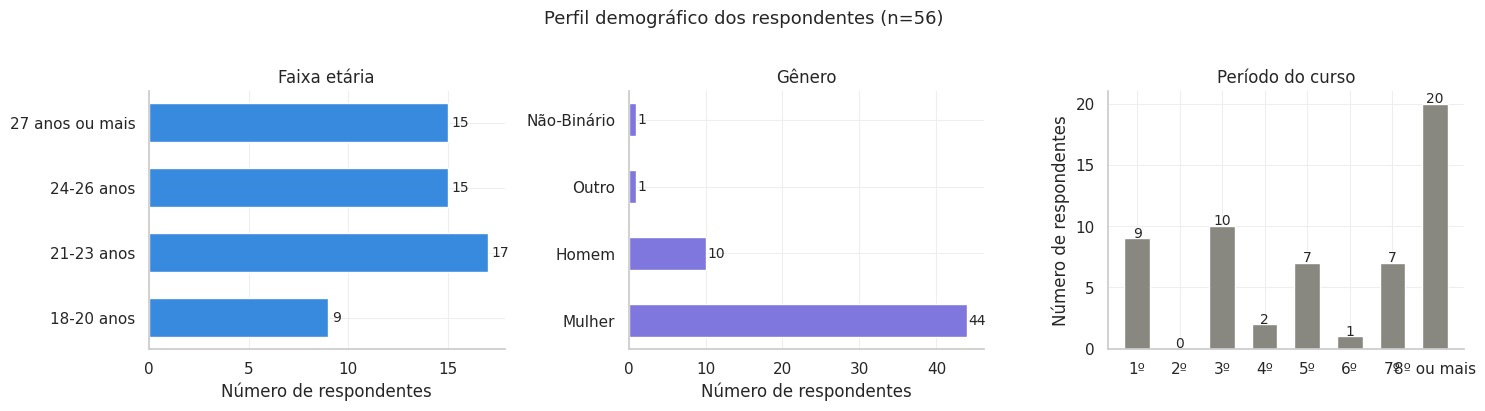

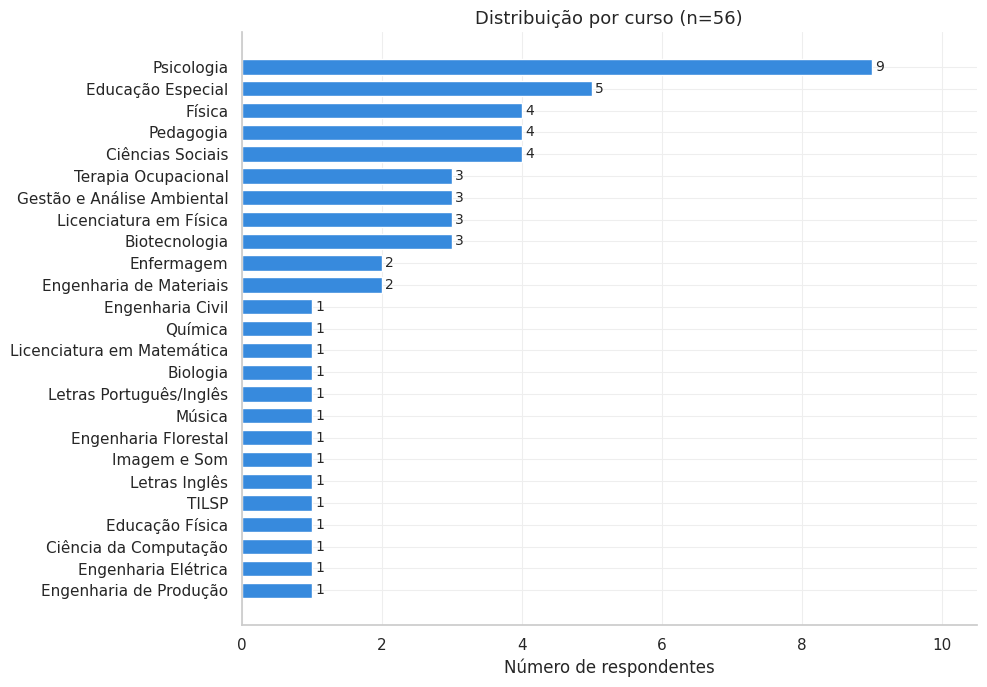

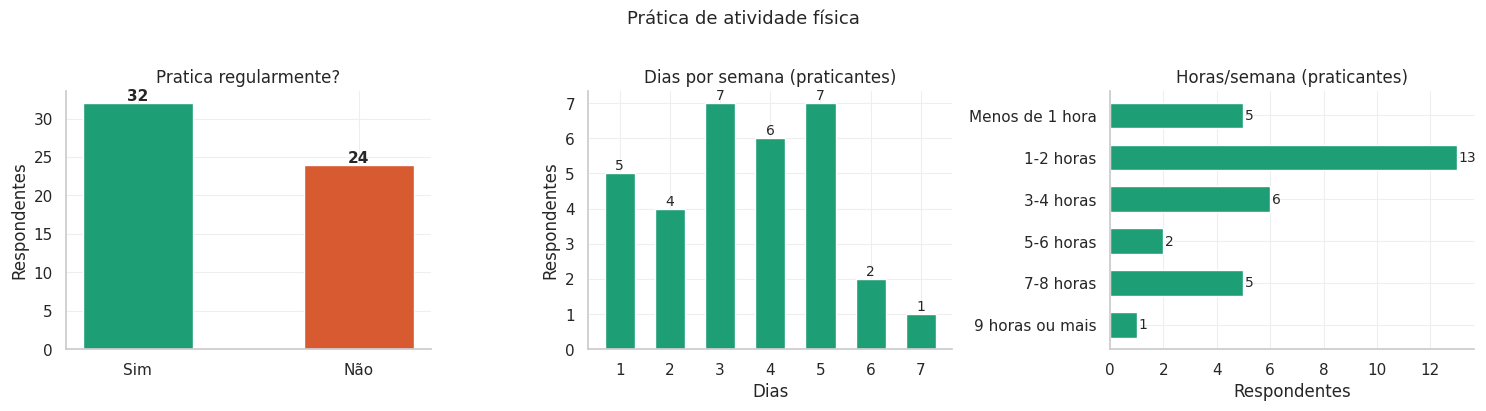

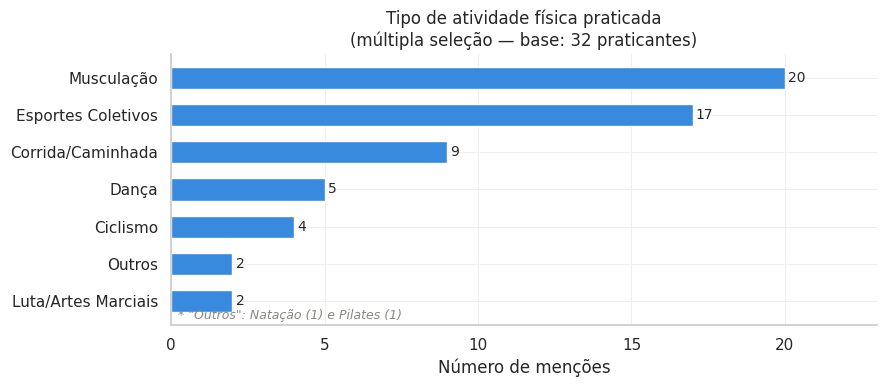

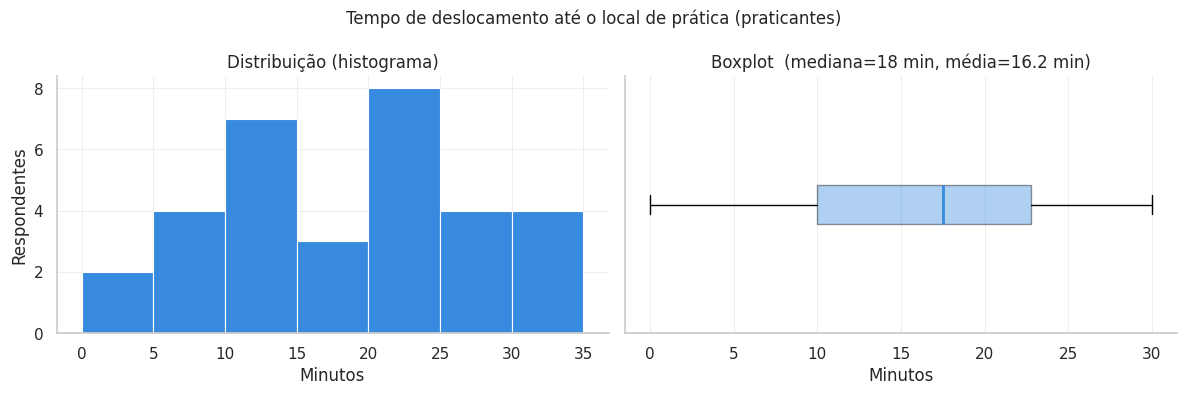

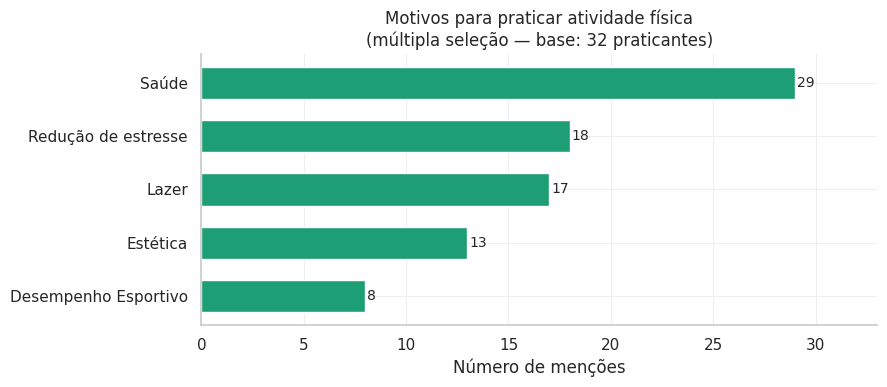

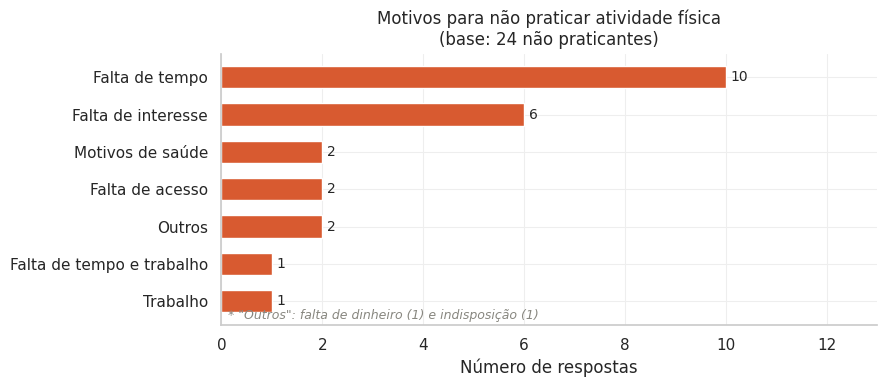

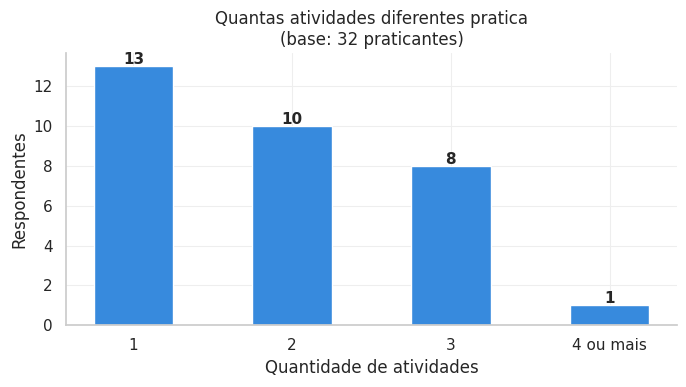

In [ ]:
# ============================================================
# PLOT DAS RESPOSTAS INICIAIS
# Pesquisa: Atividade Física entre Universitários — UFSCar São Carlos
# ============================================================
# Pré-requisito: df_limpo gerado pelo script limpeza_dados.py
# ============================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

# Paleta e estilo global
CORES = {
    "azul":   "#378ADD",
    "verde":  "#1D9E75",
    "coral":  "#D85A30",
    "roxo":   "#7F77DD",
    "cinza":  "#888780",
}
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.grid":        True,
    "grid.color":       "#eeeeee",
    "grid.linewidth":   0.8,
    "font.family":      "sans-serif",
    "font.size":        11,
})


# ── CÉLULA 1 — Perfil demográfico ────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Perfil demográfico dos respondentes (n=56)", fontsize=13, y=1.02)

col_etaria  = "Qual é a sua faixa etária?"
col_genero  = "Como você se identifica em relação ao gênero? "
col_periodo = "Em que período do curso você está? "

ordem_etaria  = ["18-20 anos", "21-23 anos", "24-26 anos", "27 anos ou mais"]
ordem_periodo = ["1º","2º","3º","4º","5º","6º","7º","8º ou mais"]

# Faixa etária
vc_etaria = df_limpo[col_etaria].value_counts().reindex(ordem_etaria, fill_value=0)
axes[0].barh(vc_etaria.index, vc_etaria.values, color=CORES["azul"], height=0.6)
axes[0].set_title("Faixa etária")
axes[0].set_xlabel("Número de respondentes")
for i, v in enumerate(vc_etaria.values):
    axes[0].text(v + 0.2, i, str(v), va="center", fontsize=10)

# Gênero
vc_gen = df_limpo[col_genero].value_counts()
axes[1].barh(vc_gen.index, vc_gen.values, color=CORES["roxo"], height=0.5)
axes[1].set_title("Gênero")
axes[1].set_xlabel("Número de respondentes")
for i, v in enumerate(vc_gen.values):
    axes[1].text(v + 0.2, i, str(v), va="center", fontsize=10)

# Período
vc_per = df_limpo[col_periodo].value_counts().reindex(ordem_periodo, fill_value=0)
axes[2].bar(vc_per.index, vc_per.values, color=CORES["cinza"], width=0.6)
axes[2].set_title("Período do curso")
axes[2].set_ylabel("Número de respondentes")
for i, v in enumerate(vc_per.values):
    axes[2].text(i, v + 0.1, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.savefig("plot_perfil_demografico.png", dpi=150, bbox_inches="tight")
plt.show()


# ── CÉLULA 2 — Distribuição por curso ────────────────────────
col_curso = "Qual é o seu curso?"
vc_curso = df_limpo[col_curso].value_counts()

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(vc_curso.index[::-1], vc_curso.values[::-1], color=CORES["azul"], height=0.7)
ax.set_title("Distribuição por curso (n=56)", fontsize=13)
ax.set_xlabel("Número de respondentes")
for i, v in enumerate(vc_curso.values[::-1]):
    ax.text(v + 0.05, i, str(v), va="center", fontsize=10)
ax.set_xlim(0, vc_curso.max() + 1.5)
plt.tight_layout()
plt.savefig("plot_cursos.png", dpi=150, bbox_inches="tight")
plt.show()


# ── CÉLULA 3 — Prática de atividade física ───────────────────
col_pratica = "Você pratica alguma atividade física regularmente?"
vc_pratica  = df_limpo[col_pratica].value_counts()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Prática de atividade física", fontsize=13, y=1.02)

# Pratica ou não
cores_prat = [CORES["verde"], CORES["coral"]]
axes[0].bar(vc_pratica.index, vc_pratica.values, color=cores_prat, width=0.5)
axes[0].set_title("Pratica regularmente?")
axes[0].set_ylabel("Respondentes")
for i, v in enumerate(vc_pratica.values):
    axes[0].text(i, v + 0.3, str(v), ha="center", fontsize=11, fontweight="bold")

# Dias por semana (só praticantes)
col_dias = "Quantos dias por semana você pratica atividade física?"
vc_dias  = df_limpo[col_dias].dropna().astype(int).value_counts().sort_index()
axes[1].bar(vc_dias.index.astype(str), vc_dias.values, color=CORES["verde"], width=0.6)
axes[1].set_title("Dias por semana (praticantes)")
axes[1].set_xlabel("Dias")
axes[1].set_ylabel("Respondentes")
for i, v in enumerate(vc_dias.values):
    axes[1].text(i, v + 0.1, str(v), ha="center", fontsize=10)

# Horas por semana (só praticantes)
col_horas_label = "Em média, quantas horas por semana você dedica à atividade física? "
ordem_horas = ["Menos de 1 hora","1-2 horas","3-4 horas","5-6 horas","7-8 horas","9 horas ou mais"]
vc_horas = df_limpo[col_horas_label].dropna().value_counts().reindex(ordem_horas, fill_value=0)
axes[2].barh(vc_horas.index[::-1], vc_horas.values[::-1], color=CORES["verde"], height=0.6)
axes[2].set_title("Horas/semana (praticantes)")
axes[2].set_xlabel("Respondentes")
for i, v in enumerate(vc_horas.values[::-1]):
    axes[2].text(v + 0.05, i, str(v), va="center", fontsize=10)

plt.tight_layout()
plt.savefig("plot_pratica_geral.png", dpi=150, bbox_inches="tight")
plt.show()


# ── CÉLULA 4 — Atividades praticadas (explodido) ─────────────
from collections import Counter

freq_ativ = Counter(
    a for lista in df_limpo["atividade_lista"].dropna() for a in lista
)
labels_a, vals_a = zip(*freq_ativ.most_common())

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(list(labels_a)[::-1], list(vals_a)[::-1],
               color=CORES["azul"], height=0.6)
ax.set_title("Tipo de atividade física praticada\n(múltipla seleção — base: 32 praticantes)", fontsize=12)
ax.set_xlabel("Número de menções")
for i, v in enumerate(list(vals_a)[::-1]):
    ax.text(v + 0.1, i, str(v), va="center", fontsize=10)
ax.set_xlim(0, max(vals_a) + 3)
ax.annotate('* "Outros": Natação (1) e Pilates (1)',
            xy=(0.01, 0.02), xycoords='axes fraction',
            fontsize=9, color=CORES["cinza"], style="italic")
plt.tight_layout()
plt.savefig("plot_atividades.png", dpi=150, bbox_inches="tight")
plt.show()


# ── CÉLULA 5 — Deslocamento até o local de prática ───────────
desloc = df_limpo["deslocamento_min"].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Tempo de deslocamento até o local de prática (praticantes)", fontsize=12)

# Histograma
axes[0].hist(desloc, bins=range(0, int(desloc.max()) + 10, 5),
             color=CORES["azul"], edgecolor="white", linewidth=0.8)
axes[0].set_xlabel("Minutos")
axes[0].set_ylabel("Respondentes")
axes[0].set_title("Distribuição (histograma)")

# Boxplot
axes[1].boxplot(desloc, vert=False, patch_artist=True,
                boxprops=dict(facecolor=CORES["azul"], alpha=0.4),
                medianprops=dict(color=CORES["azul"], linewidth=2),
                flierprops=dict(marker='o', color=CORES["coral"], markersize=6))
axes[1].set_xlabel("Minutos")
axes[1].set_title(f"Boxplot  (mediana={desloc.median():.0f} min, média={desloc.mean():.1f} min)")
axes[1].set_yticks([])

plt.tight_layout()
plt.savefig("plot_deslocamento.png", dpi=150, bbox_inches="tight")
plt.show()


# ── CÉLULA 6 — Motivos para praticar atividade física ────────
freq_mot_sim = Counter(
    m for lista in df_limpo["motivo_sim_lista"].dropna() for m in lista
)
labels_ms, vals_ms = zip(*freq_mot_sim.most_common())

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(list(labels_ms)[::-1], list(vals_ms)[::-1],
        color=CORES["verde"], height=0.6)
ax.set_title("Motivos para praticar atividade física\n(múltipla seleção — base: 32 praticantes)", fontsize=12)
ax.set_xlabel("Número de menções")
for i, v in enumerate(list(vals_ms)[::-1]):
    ax.text(v + 0.1, i, str(v), va="center", fontsize=10)
ax.set_xlim(0, max(vals_ms) + 4)
plt.tight_layout()
plt.savefig("plot_motivos_sim.png", dpi=150, bbox_inches="tight")
plt.show()


# ── CÉLULA 7 — Motivos para não praticar ─────────────────────
freq_mot_nao = Counter(
    m for lista in df_nao["motivo_nao_lista"].dropna()
    for m in lista
)
labels_mn, vals_mn = zip(*freq_mot_nao.most_common())

fig, ax = plt.subplots(figsize=(9, 4))
ax.barh(list(labels_mn)[::-1], list(vals_mn)[::-1],
        color=CORES["coral"], height=0.6)
ax.set_title('Motivos para não praticar atividade física\n(base: 24 não praticantes)', fontsize=12)
ax.set_xlabel("Número de respostas")
for i, v in enumerate(list(vals_mn)[::-1]):
    ax.text(v + 0.1, i, str(v), va="center", fontsize=10)
ax.set_xlim(0, max(vals_mn) + 3)
ax.annotate('* "Outros": falta de dinheiro (1) e indisposição (1)',
            xy=(0.01, 0.02), xycoords='axes fraction',
            fontsize=9, color=CORES["cinza"], style="italic")
plt.tight_layout()
plt.savefig("plot_motivos_nao.png", dpi=150, bbox_inches="tight")
plt.show()


# ── CÉLULA 8 — Quantas atividades pratica ────────────────────
col_qtd = "Quantas atividades físicas diferentes você pratica regularmente? "
vc_qtd  = df_limpo[col_qtd].dropna().value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(vc_qtd.index.astype(str), vc_qtd.values, color=CORES["azul"], width=0.5)
ax.set_title("Quantas atividades diferentes pratica\n(base: 32 praticantes)", fontsize=12)
ax.set_xlabel("Quantidade de atividades")
ax.set_ylabel("Respondentes")
for i, v in enumerate(vc_qtd.values):
    ax.text(i, v + 0.1, str(v), ha="center", fontsize=11, fontweight="bold")
plt.tight_layout()
plt.savefig("plot_qtd_atividades.png", dpi=150, bbox_inches="tight")
plt.show()


## 5.1 Medidas de Tendência Central e Dispersão

Antes de realizar os cruzamentos entre variáveis, foram calculadas medidas
de tendência central e dispersão para as três variáveis numéricas do estudo.
Estas medidas se aplicam exclusivamente a variáveis contínuas ou ordinais
— as demais (gênero, curso, modalidade, motivos) são categóricas e
descrevem-se apenas por frequência e proporção.

As variáveis analisadas foram, considerando apenas os 32 praticantes:

- **Dias por semana:** variável discreta ordinal (1 a 7).
- **Horas por semana:** contínua por aproximação — cada faixa de resposta
  foi convertida ao seu ponto médio (ex.: "1-2 horas" → 1,5 h).
- **Deslocamento até o local de prática (min):** única variável
  verdadeiramente contínua, extraída de campo aberto.

**Por que mediana e não só a média?**
A média é sensível a valores extremos. Como o deslocamento e as horas
podem ter distribuição assimétrica — poucos estudantes com valores muito
altos — a mediana representa melhor o centro real da distribuição.

**Por que o coeficiente de variação (CV)?**
O desvio padrão sozinho depende da escala de cada variável, dificultando
comparações. O CV expressa a dispersão como percentual da média, tornando
as três variáveis comparáveis entre si.

**Identificação de outliers:**
Foram verificados outliers pela regra do IQR (valores abaixo de
Q1 − 1,5×IQR ou acima de Q3 + 1,5×IQR).

**Código — medidas de tendência central e dispersão:**

MEDIDAS DE TENDÊNCIA CENTRAL E DISPERSÃO
               Dias por semana  Horas por semana  Deslocamento (min)
n                        32.00             32.00               32.00
Média                     3.50              3.14               16.25
Mediana                   3.50              1.50               17.50
Desvio Padrão             1.65              2.61                8.84
CV (%)                   47.00             83.10               54.40
Mínimo                    1.00              0.50                0.00
Q1                        2.00              1.50               10.00
Q3                        5.00              4.00               22.75
IQR                       3.00              2.50               12.75
Máximo                    7.00              9.00               30.00
Amplitude                 6.00              8.50               30.00

── Outliers identificados pela regra IQR (1.5×) ──
  Dias por semana: nenhum outlier
  Horas por semana: 1 outlier(s) → [9.]
  Des

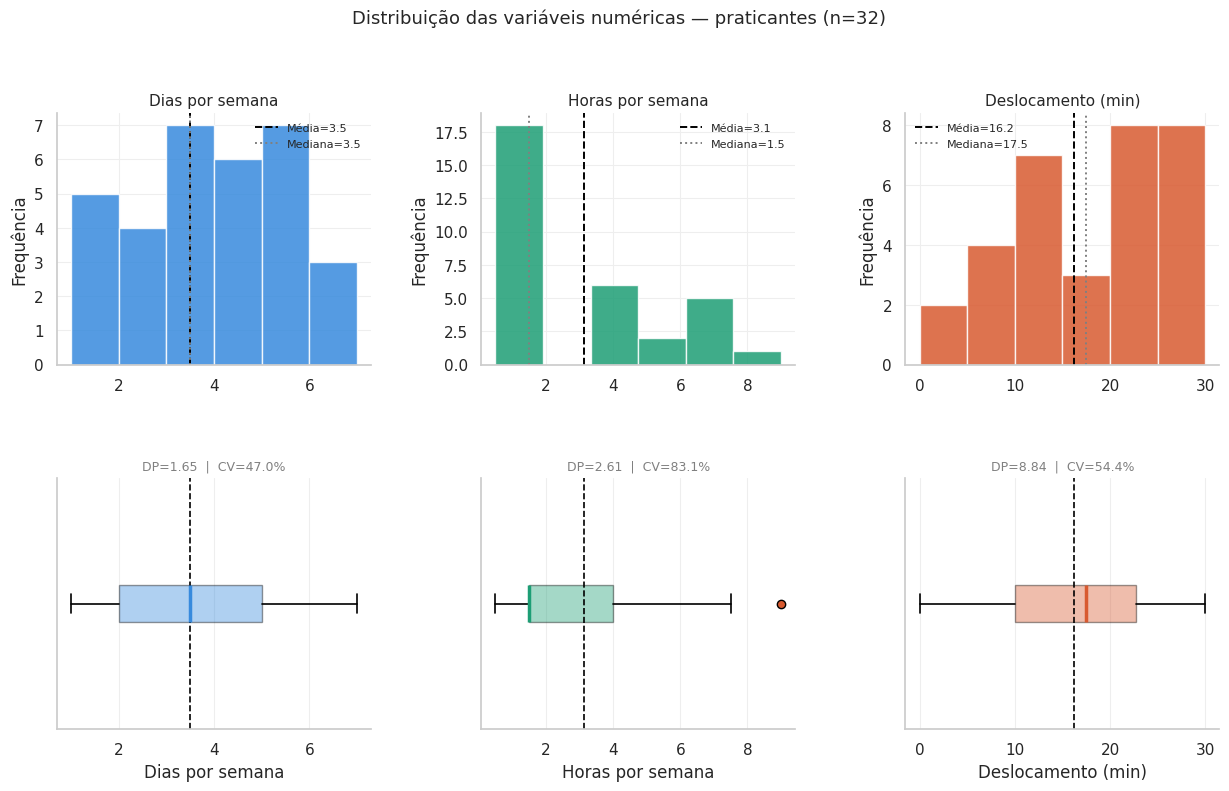

In [ ]:
# ============================================================
# MEDIDAS DE TENDÊNCIA CENTRAL E DISPERSÃO
# Pesquisa: Atividade Física entre Universitários — UFSCar São Carlos
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── CÉLULA 1 — Tabela de medidas ─────────────────────────────

col_dias   = "Quantos dias por semana você pratica atividade física?"
col_horas  = "horas_num"
col_desloc = "deslocamento_min"

# Trabalhar só com praticantes para dias e horas
praticantes = df_limpo[df_limpo["Você pratica alguma atividade física regularmente?"] == "Sim"]

variaveis = {
    "Dias por semana":    praticantes[col_dias].dropna(),
    "Horas por semana":   praticantes[col_horas].dropna(),
    "Deslocamento (min)": praticantes[col_desloc].dropna(),
}

def resumo(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr    = q3 - q1
    return pd.Series({
        "n":               int(serie.count()),
        "Média":           round(serie.mean(), 2),
        "Mediana":         round(serie.median(), 2),
        "Desvio Padrão":   round(serie.std(), 2),
        "CV (%)":          round((serie.std() / serie.mean()) * 100, 1),
        "Mínimo":          round(serie.min(), 1),
        "Q1":              round(q1, 2),
        "Q3":              round(q3, 2),
        "IQR":             round(iqr, 2),
        "Máximo":          round(serie.max(), 1),
        "Amplitude":       round(serie.max() - serie.min(), 1),
    })

tabela = pd.DataFrame({nome: resumo(s) for nome, s in variaveis.items()})
print("=" * 60)
print("MEDIDAS DE TENDÊNCIA CENTRAL E DISPERSÃO")
print("=" * 60)
print(tabela.to_string())


# ── CÉLULA 2 — Verificação de outliers (regra do IQR) ────────
print("\n── Outliers identificados pela regra IQR (1.5×) ──")
for nome, serie in variaveis.items():
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr    = q3 - q1
    inf    = q1 - 1.5 * iqr
    sup    = q3 + 1.5 * iqr
    outs   = serie[(serie < inf) | (serie > sup)]
    if outs.empty:
        print(f"  {nome}: nenhum outlier")
    else:
        print(f"  {nome}: {len(outs)} outlier(s) → {outs.values}")


# ── CÉLULA 3 — Visualização: boxplots + histogramas ──────────
CORES = {
    "azul":  "#378ADD",
    "verde": "#1D9E75",
    "coral": "#D85A30",
}
cores_lista = [CORES["azul"], CORES["verde"], CORES["coral"]]
nomes_lista = list(variaveis.keys())
series_lista = list(variaveis.values())

fig = plt.figure(figsize=(15, 8))
fig.suptitle(
    "Distribuição das variáveis numéricas — praticantes (n=32)",
    fontsize=13, y=1.01
)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

for i, (nome, serie, cor) in enumerate(zip(nomes_lista, series_lista, cores_lista)):

    # Histograma (linha superior)
    ax_hist = fig.add_subplot(gs[0, i])
    ax_hist.hist(serie, bins="auto", color=cor, alpha=0.85, edgecolor="white")
    ax_hist.axvline(serie.mean(),   color="black", linewidth=1.4,
                    linestyle="--", label=f"Média={serie.mean():.1f}")
    ax_hist.axvline(serie.median(), color="gray",  linewidth=1.4,
                    linestyle=":",  label=f"Mediana={serie.median():.1f}")
    ax_hist.set_title(nome, fontsize=11)
    ax_hist.set_ylabel("Frequência")
    ax_hist.legend(fontsize=8, frameon=False)
    ax_hist.spines["top"].set_visible(False)
    ax_hist.spines["right"].set_visible(False)

    # Boxplot (linha inferior)
    ax_box = fig.add_subplot(gs[1, i])
    bp = ax_box.boxplot(
        serie, vert=False, patch_artist=True,
        boxprops=dict(facecolor=cor, alpha=0.4),
        medianprops=dict(color=cor, linewidth=2.5),
        whiskerprops=dict(linewidth=1.2),
        capprops=dict(linewidth=1.2),
        flierprops=dict(marker="o", color=CORES["coral"],
                        markerfacecolor=CORES["coral"], markersize=6),
    )
    media = serie.mean()
    dp    = serie.std()
    ax_box.axvline(media, color="black", linewidth=1.2, linestyle="--")
    ax_box.set_xlabel(nome)
    ax_box.set_yticks([])
    ax_box.set_title(
        f"DP={dp:.2f}  |  CV={dp/media*100:.1f}%",
        fontsize=9, color="gray"
    )
    ax_box.spines["top"].set_visible(False)
    ax_box.spines["right"].set_visible(False)

plt.savefig("plot_dispersao.png", dpi=150, bbox_inches="tight")
plt.show()


## 6. Análise por Objetivo Específico

### 6.1 Objetivo 1 — Proporção de Estudantes Ativos e Sedentários

O primeiro objetivo buscou quantificar a proporção de estudantes que
praticam atividade física regularmente em relação àqueles que não praticam,
a fim de dimensionar o nível geral de engajamento físico entre os universitários
da UFSCar campus São Carlos.

Para isso, foi calculada a proporção geral de ativos e sedentários na amostra,
seguida de uma análise estratificada por três variáveis demográficas:
gênero, faixa etária e período do curso. Essa estratificação permite
identificar se a proporção de praticantes varia conforme o perfil do estudante,
fornecendo subsídios para compreender quais grupos são mais ou menos ativos.

As proporções foram calculadas como frequência relativa dentro de cada
subgrupo, garantindo comparabilidade mesmo entre grupos de tamanhos diferentes.

**Código — Objetivo 1:**

OBJETIVO 1 — Proporção geral
  Ativos     : 32 (57.1%)
  Sedentários: 24 (42.9%)
  Total      : 56

Proporção por gênero:
Você pratica alguma atividade física regularmente?  Não  Sim  Total  Pct_Sim  \
Como você se identifica em relação ao gênero?                                  
Homem                                                 3    7     10     70.0   
Mulher                                               20   24     44     54.5   
Não-Binário                                           0    1      1    100.0   
Outro                                                 1    0      1      0.0   

Você pratica alguma atividade física regularmente?  Pct_Nao  
Como você se identifica em relação ao gênero?                
Homem                                                  30.0  
Mulher                                                 45.5  
Não-Binário                                             0.0  
Outro                                                 100.0  

Proporção por faixa etár

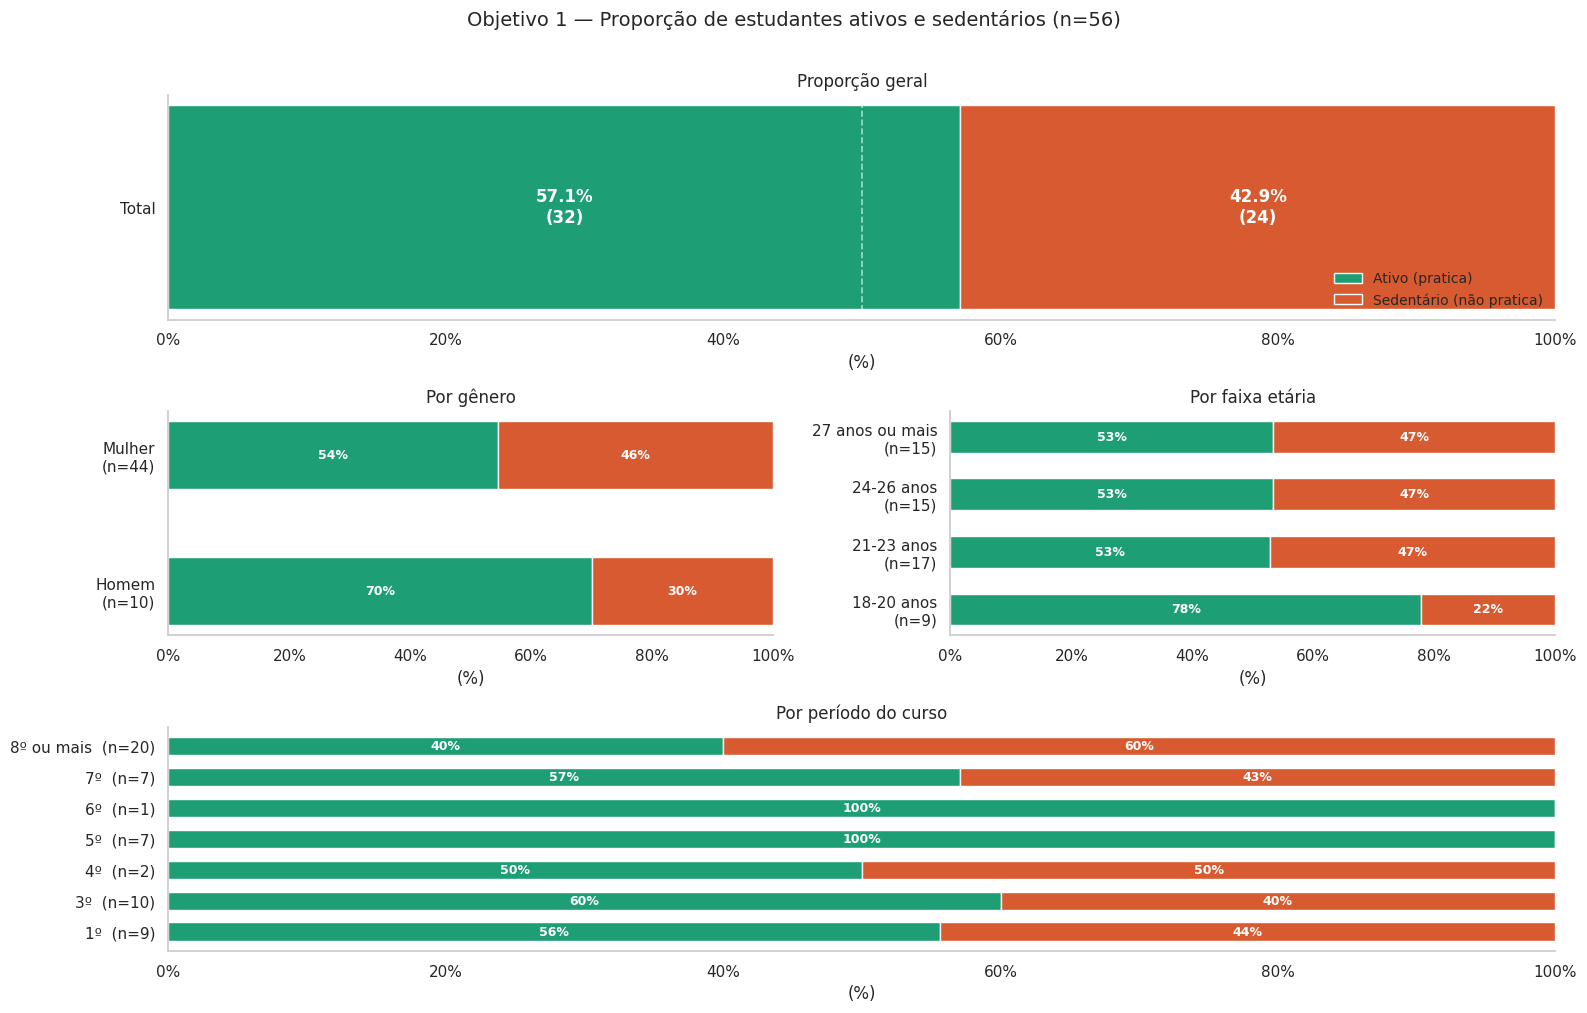

In [ ]:
# ============================================================
# OBJETIVO 1 — Proporção de estudantes ativos e sedentários
# Pesquisa: Atividade Física entre Universitários — UFSCar São Carlos
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

CORES = {
    "ativo":     "#1D9E75",
    "sedentario":"#D85A30",
    "neutro":    "#888780",
    "azul":      "#378ADD",
}

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#eeeeee",
    "grid.linewidth":    0.8,
    "font.family":       "sans-serif",
    "font.size":         11,
})

col_pratica = "Você pratica alguma atividade física regularmente?"
col_genero  = "Como você se identifica em relação ao gênero? "
col_etaria  = "Qual é a sua faixa etária?"
col_periodo = "Em que período do curso você está? "

N = len(df_limpo)


# ── CÉLULA 1 — Proporção geral ────────────────────────────────
vc = df_limpo[col_pratica].value_counts()
n_sim = vc.get("Sim", 0)
n_nao = vc.get("Não", 0)
pct_sim = round(n_sim / N * 100, 1)
pct_nao = round(n_nao / N * 100, 1)

print("=" * 50)
print("OBJETIVO 1 — Proporção geral")
print("=" * 50)
print(f"  Ativos     : {n_sim} ({pct_sim}%)")
print(f"  Sedentários: {n_nao} ({pct_nao}%)")
print(f"  Total      : {N}")


# ── CÉLULA 2 — Proporção por gênero ──────────────────────────
tab_gen = (
    df_limpo.groupby([col_genero, col_pratica])
    .size()
    .unstack(fill_value=0)
    .assign(Total=lambda x: x.sum(axis=1))
    .assign(Pct_Sim=lambda x: (x["Sim"] / x["Total"] * 100).round(1))
    .assign(Pct_Nao=lambda x: (x["Não"] / x["Total"] * 100).round(1))
)
print("\nProporção por gênero:")
print(tab_gen)


# ── CÉLULA 3 — Proporção por faixa etária ────────────────────
ordem_etaria = ["18-20 anos", "21-23 anos", "24-26 anos", "27 anos ou mais"]
tab_eta = (
    df_limpo.groupby([col_etaria, col_pratica])
    .size()
    .unstack(fill_value=0)
    .reindex(ordem_etaria)
    .assign(Total=lambda x: x.sum(axis=1))
    .assign(Pct_Sim=lambda x: (x["Sim"] / x["Total"] * 100).round(1))
    .assign(Pct_Nao=lambda x: (x["Não"] / x["Total"] * 100).round(1))
)
print("\nProporção por faixa etária:")
print(tab_eta)


# ── CÉLULA 4 — Proporção por período ─────────────────────────
ordem_periodo = ["1º","2º","3º","4º","5º","6º","7º","8º ou mais"]
tab_per = (
    df_limpo.groupby([col_periodo, col_pratica])
    .size()
    .unstack(fill_value=0)
    .reindex(ordem_periodo)
    .assign(Total=lambda x: x.sum(axis=1))
    .assign(Pct_Sim=lambda x: (x["Sim"] / x["Total"] * 100).round(1))
    .assign(Pct_Nao=lambda x: (x["Não"] / x["Total"] * 100).round(1))
)
print("\nProporção por período:")
print(tab_per)


# ── CÉLULA 5 — Visualizações ──────────────────────────────────
fig = plt.figure(figsize=(16, 10))
fig.suptitle(
    "Objetivo 1 — Proporção de estudantes ativos e sedentários (n=56)",
    fontsize=14, y=1.01
)

legend_patches = [
    Patch(facecolor=CORES["ativo"],      label="Ativo (pratica)"),
    Patch(facecolor=CORES["sedentario"], label="Sedentário (não pratica)"),
]

# --- 1A: Geral (barra única empilhada horizontal) ---
ax1 = fig.add_subplot(3, 2, (1, 2))
ax1.barh(["Total"], [pct_sim], color=CORES["ativo"],      height=0.45, label="Ativo")
ax1.barh(["Total"], [pct_nao], left=[pct_sim],
         color=CORES["sedentario"], height=0.45, label="Sedentário")
ax1.set_xlim(0, 100)
ax1.set_xlabel("(%)")
ax1.set_title("Proporção geral", fontsize=12)
ax1.xaxis.set_major_formatter(mticker.PercentFormatter())
ax1.axvline(50, color="white", linewidth=1.2, linestyle="--", alpha=0.6)
ax1.text(pct_sim / 2,          0, f"{pct_sim}%\n({n_sim})",
         ha="center", va="center", fontsize=12, fontweight="bold", color="white")
ax1.text(pct_sim + pct_nao / 2, 0, f"{pct_nao}%\n({n_nao})",
         ha="center", va="center", fontsize=12, fontweight="bold", color="white")
ax1.legend(handles=legend_patches, loc="lower right", frameon=False, fontsize=10)
ax1.grid(False)

# --- 1B: Por gênero ---
ax2 = fig.add_subplot(3, 2, 3)
gen_validos = tab_gen[tab_gen["Total"] >= 2]   # exclui grupos com n muito pequeno
barras = range(len(gen_validos))
ax2.barh(barras, gen_validos["Pct_Sim"], color=CORES["ativo"],      height=0.5)
ax2.barh(barras, gen_validos["Pct_Nao"], left=gen_validos["Pct_Sim"],
         color=CORES["sedentario"], height=0.5)
ax2.set_yticks(list(barras))
ax2.set_yticklabels([f"{g}\n(n={int(r.Total)})"
                     for g, r in gen_validos.iterrows()])
ax2.set_xlim(0, 100)
ax2.set_xlabel("(%)")
ax2.set_title("Por gênero", fontsize=12)
ax2.xaxis.set_major_formatter(mticker.PercentFormatter())
for i, (_, row) in enumerate(gen_validos.iterrows()):
    ax2.text(row["Pct_Sim"] / 2,              i, f"{row['Pct_Sim']:.0f}%",
             ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    ax2.text(row["Pct_Sim"] + row["Pct_Nao"] / 2, i, f"{row['Pct_Nao']:.0f}%",
             ha="center", va="center", fontsize=9, color="white", fontweight="bold")
ax2.grid(False)

# --- 1C: Por faixa etária ---
ax3 = fig.add_subplot(3, 2, 4)
tab_eta_v = tab_eta.dropna()
barras_e  = range(len(tab_eta_v))
ax3.barh(barras_e, tab_eta_v["Pct_Sim"], color=CORES["ativo"],      height=0.55)
ax3.barh(barras_e, tab_eta_v["Pct_Nao"], left=tab_eta_v["Pct_Sim"],
         color=CORES["sedentario"], height=0.55)
ax3.set_yticks(list(barras_e))
ax3.set_yticklabels([f"{g}\n(n={int(r.Total)})"
                     for g, r in tab_eta_v.iterrows()])
ax3.set_xlim(0, 100)
ax3.set_xlabel("(%)")
ax3.set_title("Por faixa etária", fontsize=12)
ax3.xaxis.set_major_formatter(mticker.PercentFormatter())
for i, (_, row) in enumerate(tab_eta_v.iterrows()):
    if row["Pct_Sim"] > 8:
        ax3.text(row["Pct_Sim"] / 2, i, f"{row['Pct_Sim']:.0f}%",
                 ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    if row["Pct_Nao"] > 8:
        ax3.text(row["Pct_Sim"] + row["Pct_Nao"] / 2, i, f"{row['Pct_Nao']:.0f}%",
                 ha="center", va="center", fontsize=9, color="white", fontweight="bold")
ax3.grid(False)

# --- 1D: Por período (agrupado: iniciais 1-4, intermediários 5-7, finais 8+) ---
ax4 = fig.add_subplot(3, 2, (5, 6))
tab_per_v = tab_per.dropna()
barras_p  = range(len(tab_per_v))
ax4.barh(barras_p, tab_per_v["Pct_Sim"], color=CORES["ativo"],      height=0.6)
ax4.barh(barras_p, tab_per_v["Pct_Nao"], left=tab_per_v["Pct_Sim"],
         color=CORES["sedentario"], height=0.6)
ax4.set_yticks(list(barras_p))
ax4.set_yticklabels([f"{g}  (n={int(r.Total)})"
                     for g, r in tab_per_v.iterrows()])
ax4.set_xlim(0, 100)
ax4.set_xlabel("(%)")
ax4.set_title("Por período do curso", fontsize=12)
ax4.xaxis.set_major_formatter(mticker.PercentFormatter())
for i, (_, row) in enumerate(tab_per_v.iterrows()):
    if row["Pct_Sim"] > 8:
        ax4.text(row["Pct_Sim"] / 2, i, f"{row['Pct_Sim']:.0f}%",
                 ha="center", va="center", fontsize=9, color="white", fontweight="bold")
    if row["Pct_Nao"] > 8:
        ax4.text(row["Pct_Sim"] + row["Pct_Nao"] / 2, i, f"{row['Pct_Nao']:.0f}%",
                 ha="center", va="center", fontsize=9, color="white", fontweight="bold")
ax4.grid(False)

plt.tight_layout()
plt.savefig("plot_objetivo1.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.2 Objetivo 2 — Modalidades de Atividade Física Mais Praticadas

O segundo objetivo buscou identificar as modalidades de atividade física
mais praticadas pelos estudantes, caracterizando o perfil de escolha e
preferência dos universitários em relação ao exercício físico.

Como o formulário permitia múltipla seleção, cada modalidade foi
contabilizada de forma independente — assim, o total de menções pode
superar o número de praticantes (n=32). As proporções foram calculadas
em relação ao total de praticantes, indicando em quantos por cento deles
cada modalidade aparece.

A análise foi conduzida em quatro dimensões:

- **Frequência geral:** ranking das modalidades por número de menções
  e proporção de praticantes;
- **Perfil de prática:** proporção entre quem pratica apenas uma
  atividade e quem combina duas ou mais modalidades;
- **Modalidade × gênero:** comparação das preferências entre
  estudantes do gênero masculino e feminino;
- **Modalidade × faixa etária:** verificação de possíveis variações
  nas escolhas conforme a idade do estudante, apresentada em heatmap.

Vale destacar que respostas do campo "Outros" — correspondentes a
Natação (1 estudante) e Pilates (1 estudante) — foram agrupadas
sob essa categoria, mas os valores originais foram preservados
internamente para fins de rastreabilidade.

**Código

OBJETIVO 2 — Frequência das modalidades
Modalidade                   n   % praticantes
-------------------------------------------------------
  Musculação                20           62.5%
  Esportes Coletivos        17           53.1%
  Corrida/Caminhada          9           28.1%
  Dança                      5           15.6%
  Ciclismo                   4           12.5%
  Outros                     2            6.2%
  Luta/Artes Marciais        2            6.2%

  * Base: 32 praticantes | múltipla seleção
  * 'Outros': Natação (1) e Pilates (1)

── Quantidade de atividades por praticante:
  Pratica só 1 atividade   : 14  (43.8%)
  Pratica mais de 1        : 18  (56.2%)

  Distribuição declarada:
Quantas atividades físicas diferentes você pratica regularmente? 
1            13
2            10
3             8
4 ou mais     1

── Modalidade × Gênero (% dentro de cada grupo):
                     Homem  Mulher
Musculação            57.1    62.5
Esportes Coletivos    57.1    50.0
Corr

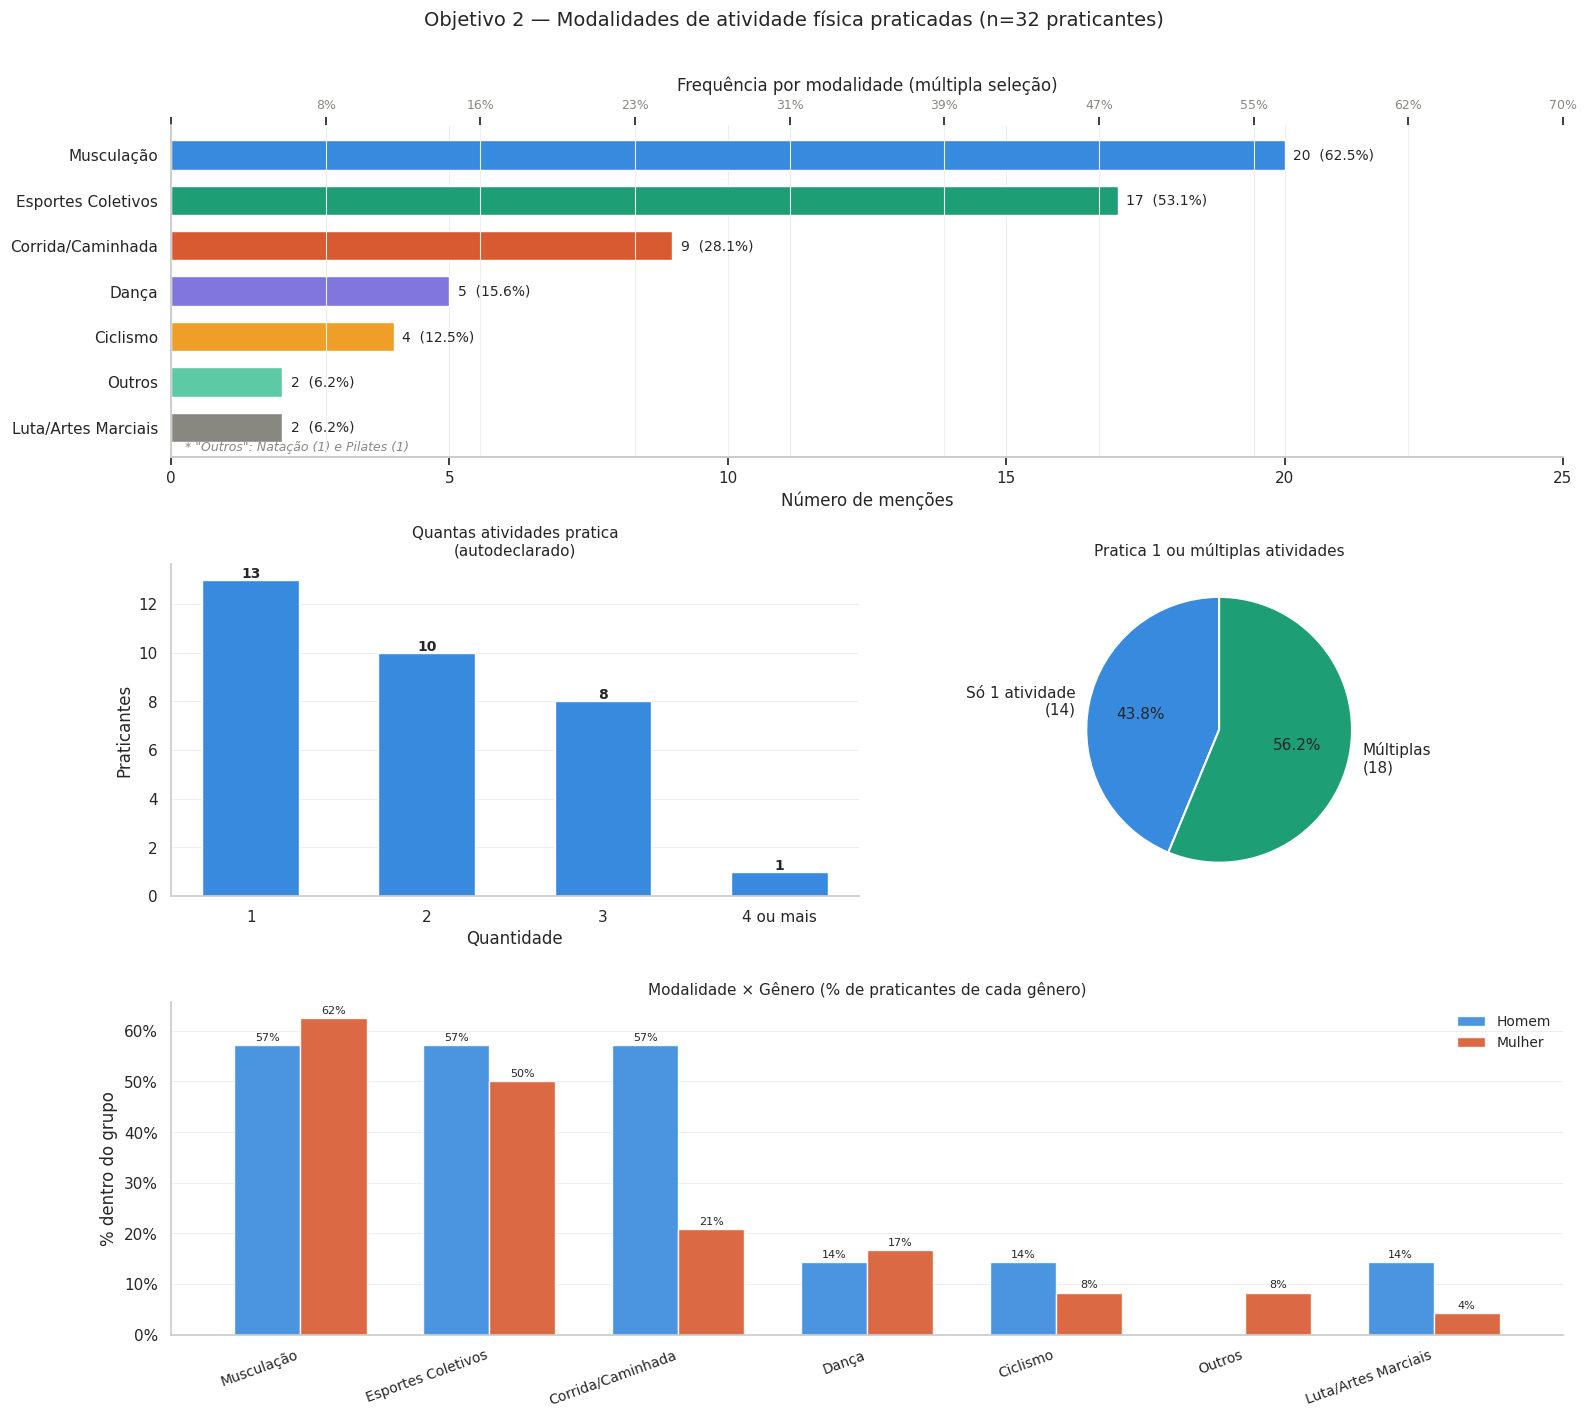

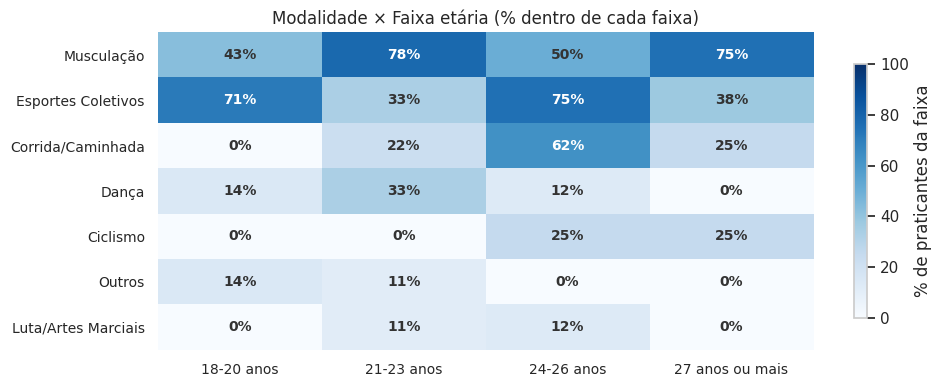

In [ ]:
# ============================================================
# OBJETIVO 2 — Modalidades de atividade física mais praticadas
# Pesquisa: Atividade Física entre Universitários — UFSCar São Carlos
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from itertools import combinations
from matplotlib.patches import Patch

CORES = {
    "azul":      "#378ADD",
    "verde":     "#1D9E75",
    "coral":     "#D85A30",
    "roxo":      "#7F77DD",
    "ambar":     "#EF9F27",
    "cinza":     "#888780",
    "teal":      "#5DCAA5",
}

PALETA_ATIV = [
    CORES["azul"], CORES["verde"], CORES["coral"],
    CORES["roxo"], CORES["ambar"], CORES["teal"], CORES["cinza"],
]

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#eeeeee",
    "grid.linewidth":    0.8,
    "font.family":       "sans-serif",
    "font.size":         11,
})

col_pratica = "Você pratica alguma atividade física regularmente?"
col_genero  = "Como você se identifica em relação ao gênero? "
col_etaria  = "Qual é a sua faixa etária?"
col_qtd     = "Quantas atividades físicas diferentes você pratica regularmente? "

praticantes = df_limpo[df_limpo[col_pratica] == "Sim"].copy()
N_prat = len(praticantes)   # 32


# ── CÉLULA 1 — Frequência individual de cada modalidade ──────
freq_ativ = Counter(
    a for lista in praticantes["atividade_lista"].dropna() for a in lista
)
labels_a = [k for k, _ in freq_ativ.most_common()]
vals_a   = [v for _, v in freq_ativ.most_common()]
pct_a    = [round(v / N_prat * 100, 1) for v in vals_a]

print("=" * 55)
print("OBJETIVO 2 — Frequência das modalidades")
print("=" * 55)
print(f"{'Modalidade':<25} {'n':>4}  {'% praticantes':>14}")
print("-" * 55)
for lab, val, pct in zip(labels_a, vals_a, pct_a):
    print(f"  {lab:<23} {val:>4}  {pct:>13.1f}%")
print(f"\n  * Base: {N_prat} praticantes | múltipla seleção")
print(f"  * 'Outros': Natação (1) e Pilates (1)")


# ── CÉLULA 2 — Perfil: só 1 vs. múltiplas atividades ─────────
so_um      = praticantes["atividade_lista"].dropna().apply(lambda x: len(x) == 1).sum()
multiplas  = praticantes["atividade_lista"].dropna().apply(lambda x: len(x) > 1).sum()

print("\n── Quantidade de atividades por praticante:")
print(f"  Pratica só 1 atividade   : {so_um}  ({so_um/N_prat*100:.1f}%)")
print(f"  Pratica mais de 1        : {multiplas}  ({multiplas/N_prat*100:.1f}%)")

qtd_ativ = praticantes[col_qtd].dropna().value_counts().sort_index()
print("\n  Distribuição declarada:")
print(qtd_ativ.to_string())


# ── CÉLULA 3 — Modalidade × Gênero ───────────────────────────
generos_principais = ["Homem", "Mulher"]
tab_gen_ativ = {}

for genero in generos_principais:
    sub = praticantes[praticantes[col_genero] == genero]
    n   = len(sub)
    freq = Counter(a for lista in sub["atividade_lista"].dropna() for a in lista)
    tab_gen_ativ[genero] = {k: round(v / n * 100, 1) for k, v in freq.items()}

df_gen_ativ = pd.DataFrame(tab_gen_ativ).fillna(0).loc[labels_a]
print("\n── Modalidade × Gênero (% dentro de cada grupo):")
print(df_gen_ativ.round(1).to_string())


# ── CÉLULA 4 — Modalidade × Faixa etária ─────────────────────
ordem_etaria = ["18-20 anos", "21-23 anos", "24-26 anos", "27 anos ou mais"]
tab_eta_ativ = {}

for faixa in ordem_etaria:
    sub = praticantes[praticantes[col_etaria] == faixa]
    if len(sub) == 0:
        continue
    n   = len(sub)
    freq = Counter(a for lista in sub["atividade_lista"].dropna() for a in lista)
    tab_eta_ativ[faixa] = {k: round(v / n * 100, 1) for k, v in freq.items()}

df_eta_ativ = pd.DataFrame(tab_eta_ativ).fillna(0).loc[labels_a]
print("\n── Modalidade × Faixa etária (% dentro de cada grupo):")
print(df_eta_ativ.round(1).to_string())


# ── CÉLULA 5 — Visualizações ──────────────────────────────────
fig = plt.figure(figsize=(16, 14))
fig.suptitle(
    "Objetivo 2 — Modalidades de atividade física praticadas (n=32 praticantes)",
    fontsize=14, y=1.01
)

# --- 2A: Frequência geral (barras horizontais) ---
ax1 = fig.add_subplot(3, 2, (1, 2))
cores_barras = PALETA_ATIV[:len(labels_a)]
bars = ax1.barh(
    labels_a[::-1], vals_a[::-1],
    color=cores_barras[::-1], height=0.65
)
ax1.set_xlabel("Número de menções")
ax1.set_title("Frequência por modalidade (múltipla seleção)", fontsize=12)
ax2_twin = ax1.twiny()
ax2_twin.set_xlim(ax1.get_xlim())
ax2_twin.set_xticks(ax1.get_xticks())
ax2_twin.set_xticklabels(
    [f"{round(t/N_prat*100)}%" if t > 0 else "" for t in ax1.get_xticks()],
    fontsize=9, color=CORES["cinza"]
)
ax2_twin.spines["top"].set_visible(False)
for i, (v, p) in enumerate(zip(vals_a[::-1], pct_a[::-1])):
    ax1.text(v + 0.15, i, f"{v}  ({p}%)", va="center", fontsize=10)
ax1.set_xlim(0, max(vals_a) + 5)
ax1.annotate('* "Outros": Natação (1) e Pilates (1)',
             xy=(0.01, 0.02), xycoords="axes fraction",
             fontsize=9, color=CORES["cinza"], style="italic")
ax1.grid(axis="y", visible=False)

# --- 2B: Quantidade de atividades por praticante ---
ax3 = fig.add_subplot(3, 2, 3)
ax3.bar(qtd_ativ.index.astype(str), qtd_ativ.values,
        color=CORES["azul"], width=0.55)
ax3.set_title("Quantas atividades pratica\n(autodeclarado)", fontsize=11)
ax3.set_xlabel("Quantidade")
ax3.set_ylabel("Praticantes")
for i, v in enumerate(qtd_ativ.values):
    ax3.text(i, v + 0.1, str(v), ha="center", fontsize=10, fontweight="bold")
ax3.grid(axis="x", visible=False)

# --- 2C: Só 1 vs. múltiplas (pizza) ---
ax4 = fig.add_subplot(3, 2, 4)
ax4.pie(
    [so_um, multiplas],
    labels=[f"Só 1 atividade\n({so_um})", f"Múltiplas\n({multiplas})"],
    colors=[CORES["azul"], CORES["verde"]],
    autopct="%1.1f%%", startangle=90,
    textprops={"fontsize": 11},
    wedgeprops={"linewidth": 1.5, "edgecolor": "white"},
)
ax4.set_title("Pratica 1 ou múltiplas atividades", fontsize=11)

# --- 2D: Modalidade × Gênero (barras agrupadas) ---
ax5 = fig.add_subplot(3, 2, (5, 6))
x     = np.arange(len(labels_a))
width = 0.35
bars1 = ax5.bar(x - width/2, df_gen_ativ["Homem"],  width,
                label="Homem",  color=CORES["azul"],  alpha=0.9)
bars2 = ax5.bar(x + width/2, df_gen_ativ["Mulher"], width,
                label="Mulher", color=CORES["coral"], alpha=0.9)
ax5.set_xticks(x)
ax5.set_xticklabels(labels_a, rotation=20, ha="right", fontsize=10)
ax5.set_ylabel("% dentro do grupo")
ax5.set_title("Modalidade × Gênero (% de praticantes de cada gênero)", fontsize=11)
ax5.yaxis.set_major_formatter(mticker.PercentFormatter())
ax5.legend(frameon=False, fontsize=10)
ax5.grid(axis="x", visible=False)
for bar in bars1:
    h = bar.get_height()
    if h > 3:
        ax5.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 f"{h:.0f}%", ha="center", va="bottom", fontsize=8)
for bar in bars2:
    h = bar.get_height()
    if h > 3:
        ax5.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                 f"{h:.0f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.savefig("plot_objetivo2.png", dpi=150, bbox_inches="tight")
plt.show()


# ── CÉLULA 6 — Modalidade × Faixa etária (heatmap) ───────────
fig2, ax6 = plt.subplots(figsize=(10, 4))
im = ax6.imshow(df_eta_ativ.values, aspect="auto",
                cmap="Blues", vmin=0, vmax=100)
ax6.set_xticks(range(len(df_eta_ativ.columns)))
ax6.set_xticklabels(df_eta_ativ.columns, fontsize=10)
ax6.set_yticks(range(len(df_eta_ativ.index)))
ax6.set_yticklabels(df_eta_ativ.index, fontsize=10)
ax6.set_title("Modalidade × Faixa etária (% dentro de cada faixa)", fontsize=12)
for i in range(len(df_eta_ativ.index)):
    for j in range(len(df_eta_ativ.columns)):
        val = df_eta_ativ.iloc[i, j]
        cor = "white" if val > 55 else "#333"
        ax6.text(j, i, f"{val:.0f}%", ha="center", va="center",
                 fontsize=10, color=cor, fontweight="bold")
plt.colorbar(im, ax=ax6, label="% de praticantes da faixa", shrink=0.8)
ax6.grid(False)
ax6.spines[:].set_visible(False)
plt.tight_layout()
plt.savefig("plot_objetivo2_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.3 Objetivo 3 — Frequência e Volume de Prática de Atividade Física

O terceiro objetivo visou analisar a frequência e o volume de prática
de atividade física, considerando a regularidade semanal das atividades
realizadas pelos estudantes ativos (n=32).

A análise foi organizada em cinco dimensões:

- **Distribuição de dias e horas por semana:** frequência com que
  os praticantes se exercitam e a carga horária dedicada semanalmente;
- **Volume semanal total:** calculado como o produto entre dias e horas
  por semana, fornecendo um indicador composto de engajamento físico;
- **Relação entre dias e horas (correlação de Pearson):** verificação
  de se quem pratica mais vezes por semana também dedica mais horas —
  avaliada pelo coeficiente r e sua significância estatística (p < 0,05);
- **Volume × período do curso:** análise de se a carga acadêmica,
  crescente nos períodos finais, está associada a uma redução no
  volume de atividade física; as barras de erro indicam o desvio
  padrão dentro de cada período;
- **Deslocamento × dias por semana (correlação de Pearson):** investigação
  de se o tempo de deslocamento até o local de prática influencia
  a frequência semanal dos estudantes.

A correlação de Pearson foi escolhida por ser adequada para medir
a intensidade e a direção da relação linear entre duas variáveis
contínuas. Valores de r próximos de ±1 indicam forte associação;
próximos de 0, associação fraca ou inexistente.

**Código — Objetivo 3:**

OBJETIVO 3 — Frequência e volume de prática

Dias por semana (praticantes):
  1 dia(s): 5 (15.6%)
  2 dia(s): 4 (12.5%)
  3 dia(s): 7 (21.9%)
  4 dia(s): 6 (18.8%)
  5 dia(s): 7 (21.9%)
  6 dia(s): 2 (6.2%)
  7 dia(s): 1 (3.1%)

Horas por semana (praticantes):
  Menos de 1 hora: 5 (15.6%)
  1-2 horas: 13 (40.6%)
  3-4 horas: 6 (18.8%)
  5-6 horas: 2 (6.2%)
  7-8 horas: 5 (15.6%)
  9 horas ou mais: 1 (3.1%)

Dias/semana  — média: 3.50 | mediana: 3.5 | DP: 1.65
Horas/semana — média: 3.14 | mediana: 1.5 | DP: 2.61

Volume semanal (dias × horas):
  Média  : 12.39 h
  Mediana: 8.25 h
  DP     : 12.47 h
  Mínimo : 0.50 h | Máximo: 45.00 h

Correlação Pearson (dias × horas): r=0.336, p=0.0601
  → Correlação não significativa (p ≥ 0,05)

Volume semanal (h) por período:
                                       n  media  mediana     dp
Em que período do curso você está?                             
1º                                   5.0   1.80      1.5   1.57
3º                                  

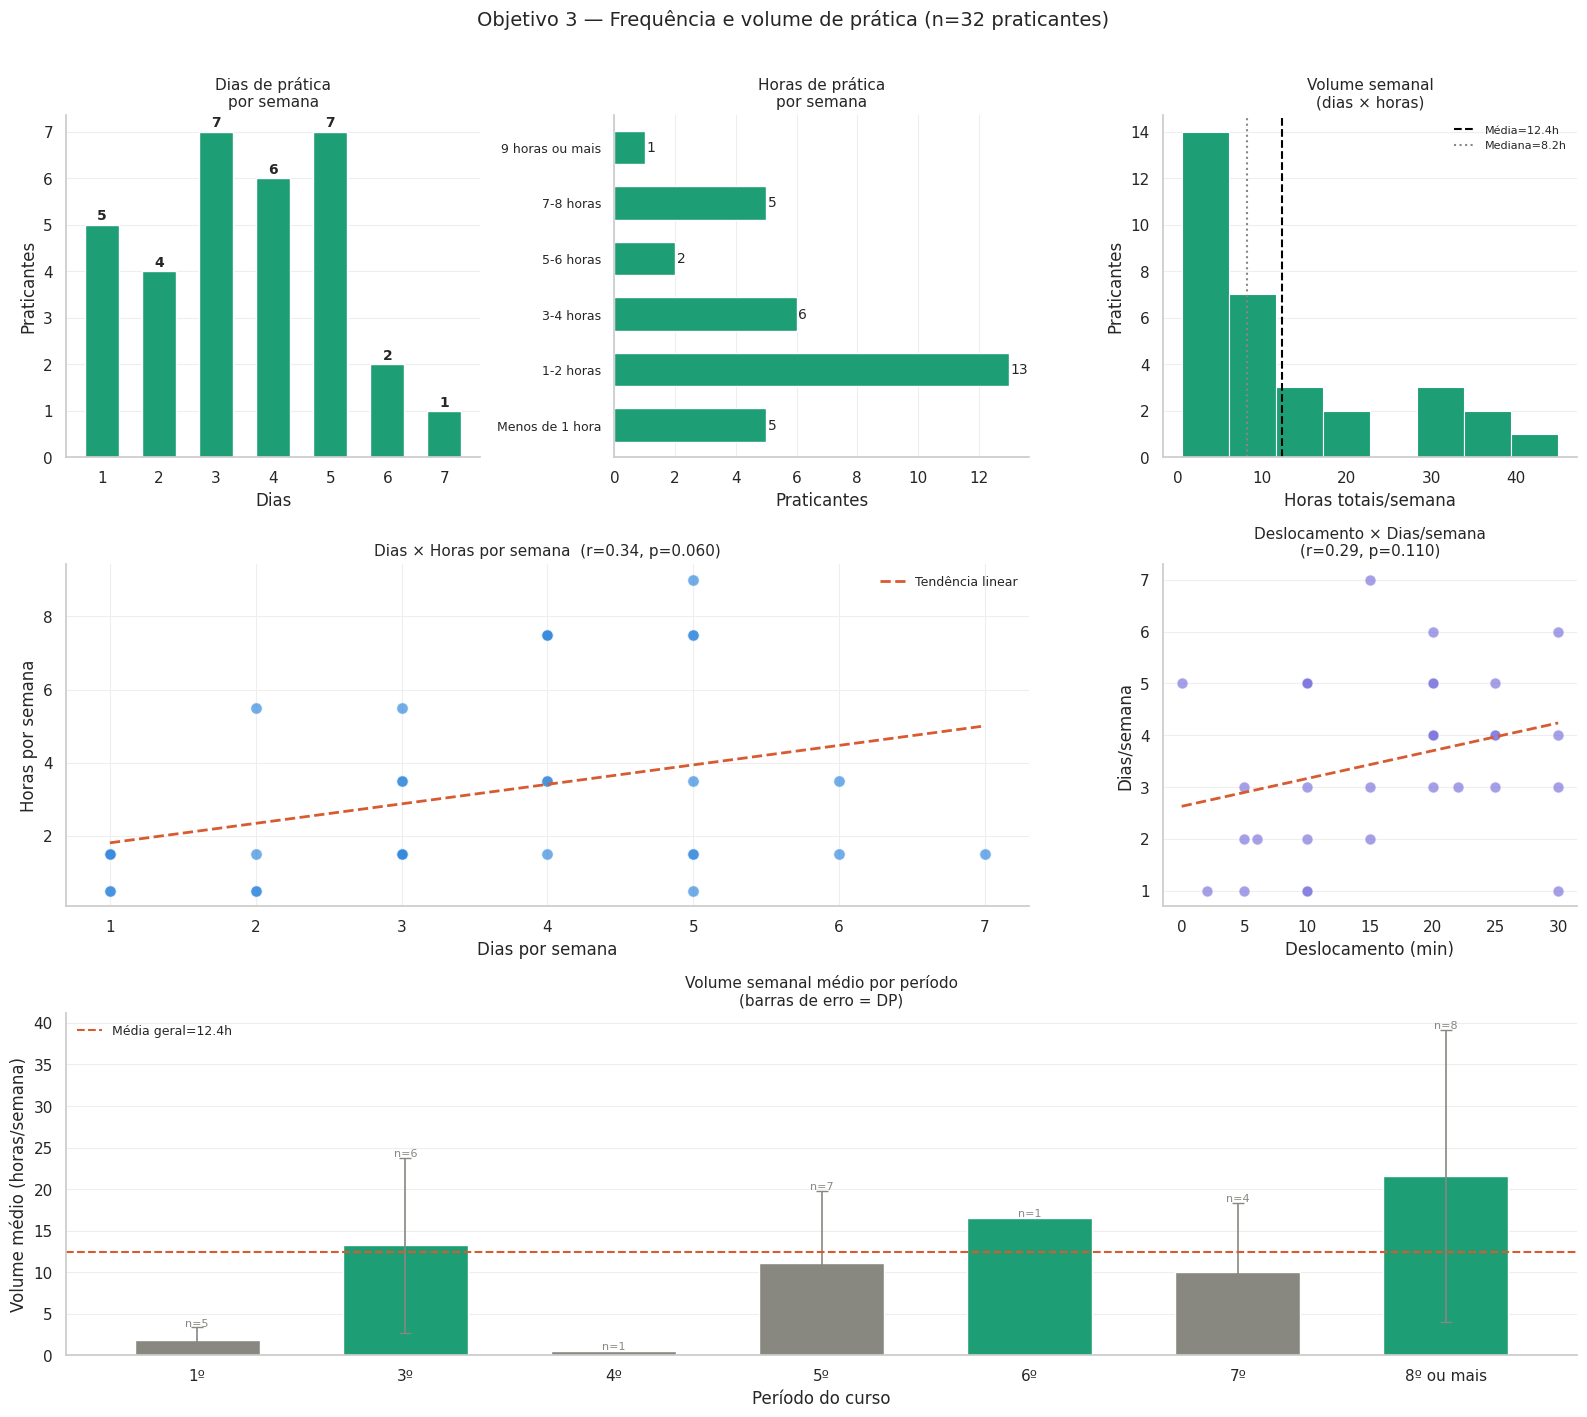

In [ ]:
# ============================================================
# OBJETIVO 3 — Frequência e volume de prática de atividade física
# Pesquisa: Atividade Física entre Universitários — UFSCar São Carlos
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats

CORES = {
    "azul":   "#378ADD",
    "verde":  "#1D9E75",
    "coral":  "#D85A30",
    "roxo":   "#7F77DD",
    "ambar":  "#EF9F27",
    "cinza":  "#888780",
}

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#eeeeee",
    "grid.linewidth":    0.8,
    "font.family":       "sans-serif",
    "font.size":         11,
})

col_pratica = "Você pratica alguma atividade física regularmente?"
col_dias    = "Quantos dias por semana você pratica atividade física?"
col_horas_l = "Em média, quantas horas por semana você dedica à atividade física? "
col_periodo = "Em que período do curso você está? "
col_desloc  = "deslocamento_min"
col_horas_n = "horas_num"

praticantes  = df_limpo[df_limpo[col_pratica] == "Sim"].copy()
N_prat = len(praticantes)   # 32

ordem_horas  = ["Menos de 1 hora","1-2 horas","3-4 horas",
                "5-6 horas","7-8 horas","9 horas ou mais"]
ordem_periodo = ["1º","2º","3º","4º","5º","6º","7º","8º ou mais"]


# ── CÉLULA 1 — Distribuição de dias e horas por semana ───────
vc_dias  = praticantes[col_dias].dropna().astype(int).value_counts().sort_index()
vc_horas = praticantes[col_horas_l].dropna().value_counts().reindex(
    ordem_horas, fill_value=0
)

print("=" * 55)
print("OBJETIVO 3 — Frequência e volume de prática")
print("=" * 55)

print("\nDias por semana (praticantes):")
for d, n in vc_dias.items():
    print(f"  {d} dia(s): {n} ({n/N_prat*100:.1f}%)")

print("\nHoras por semana (praticantes):")
for h, n in vc_horas.items():
    print(f"  {h}: {n} ({n/N_prat*100:.1f}%)")

# Estatísticas descritivas
dias_serie  = praticantes[col_dias].dropna()
horas_serie = praticantes[col_horas_n].dropna()

print(f"\nDias/semana  — média: {dias_serie.mean():.2f} | "
      f"mediana: {dias_serie.median():.1f} | DP: {dias_serie.std():.2f}")
print(f"Horas/semana — média: {horas_serie.mean():.2f} | "
      f"mediana: {horas_serie.median():.1f} | DP: {horas_serie.std():.2f}")


# ── CÉLULA 2 — Volume total (dias × horas) ───────────────────
praticantes["volume_semanal"] = (
    praticantes[col_dias].astype(float) * praticantes[col_horas_n]
)
vol = praticantes["volume_semanal"].dropna()

print(f"\nVolume semanal (dias × horas):")
print(f"  Média  : {vol.mean():.2f} h")
print(f"  Mediana: {vol.median():.2f} h")
print(f"  DP     : {vol.std():.2f} h")
print(f"  Mínimo : {vol.min():.2f} h | Máximo: {vol.max():.2f} h")


# ── CÉLULA 3 — Dias × Horas (correlação) ─────────────────────
dias_v  = praticantes[col_dias].dropna().astype(float)
horas_v = praticantes[col_horas_n].dropna()
idx_com = dias_v.index.intersection(horas_v.index)
dias_v  = dias_v.loc[idx_com]
horas_v = horas_v.loc[idx_com]

r, p = stats.pearsonr(dias_v, horas_v)
print(f"\nCorrelação Pearson (dias × horas): r={r:.3f}, p={p:.4f}")
if p < 0.05:
    print("  → Correlação estatisticamente significativa (p < 0,05)")
else:
    print("  → Correlação não significativa (p ≥ 0,05)")


# ── CÉLULA 4 — Volume × Período do curso ─────────────────────
praticantes_per = praticantes[[col_periodo, col_horas_n, col_dias]].copy()
praticantes_per["volume_semanal"] = (
    praticantes_per[col_dias].astype(float) * praticantes_per[col_horas_n]
)

tab_periodo = (
    praticantes_per.groupby(col_periodo)["volume_semanal"]
    .agg(n="count", media="mean", mediana="median", dp="std")
    .reindex(ordem_periodo)
    .dropna(subset=["media"])
    .round(2)
)
print("\nVolume semanal (h) por período:")
print(tab_periodo.to_string())


# ── CÉLULA 5 — Deslocamento × Dias por semana ────────────────
desloc_dias = praticantes[[col_desloc, col_dias]].dropna()
r2, p2 = stats.pearsonr(
    desloc_dias[col_desloc].astype(float),
    desloc_dias[col_dias].astype(float)
)
print(f"\nCorrelação Pearson (deslocamento × dias/semana): "
      f"r={r2:.3f}, p={p2:.4f}")


# ── CÉLULA 6 — Visualizações ──────────────────────────────────
fig = plt.figure(figsize=(16, 14))
fig.suptitle(
    "Objetivo 3 — Frequência e volume de prática (n=32 praticantes)",
    fontsize=14, y=1.01
)

# --- 3A: Dias por semana ---
ax1 = fig.add_subplot(3, 3, 1)
ax1.bar(vc_dias.index.astype(str), vc_dias.values,
        color=CORES["verde"], width=0.6)
ax1.set_title("Dias de prática\npor semana", fontsize=11)
ax1.set_xlabel("Dias")
ax1.set_ylabel("Praticantes")
for i, v in enumerate(vc_dias.values):
    ax1.text(i, v + 0.1, str(v), ha="center", fontsize=10, fontweight="bold")
ax1.grid(axis="x", visible=False)

# --- 3B: Horas por semana ---
ax2 = fig.add_subplot(3, 3, 2)
ax2.barh(list(range(len(ordem_horas))), vc_horas.values,
         color=CORES["verde"], height=0.6)
ax2.set_yticks(list(range(len(ordem_horas))))
ax2.set_yticklabels(ordem_horas, fontsize=9)
ax2.set_title("Horas de prática\npor semana", fontsize=11)
ax2.set_xlabel("Praticantes")
for i, v in enumerate(vc_horas.values):
    ax2.text(v + 0.05, i, str(v), va="center", fontsize=10)
ax2.grid(axis="y", visible=False)

# --- 3C: Volume semanal (histograma) ---
ax3 = fig.add_subplot(3, 3, 3)
ax3.hist(vol.dropna(), bins=8, color=CORES["verde"],
         edgecolor="white", linewidth=0.8)
ax3.axvline(vol.mean(),   color="black", linewidth=1.5,
            linestyle="--", label=f"Média={vol.mean():.1f}h")
ax3.axvline(vol.median(), color=CORES["cinza"], linewidth=1.5,
            linestyle=":",  label=f"Mediana={vol.median():.1f}h")
ax3.set_title("Volume semanal\n(dias × horas)", fontsize=11)
ax3.set_xlabel("Horas totais/semana")
ax3.set_ylabel("Praticantes")
ax3.legend(fontsize=8, frameon=False)
ax3.grid(axis="x", visible=False)

# --- 3D: Dispersão dias × horas ---
ax4 = fig.add_subplot(3, 3, (4, 5))
ax4.scatter(dias_v, horas_v, color=CORES["azul"],
            alpha=0.7, s=70, edgecolors="white", linewidth=0.8)
m, b = np.polyfit(dias_v, horas_v, 1)
x_line = np.linspace(dias_v.min(), dias_v.max(), 100)
ax4.plot(x_line, m * x_line + b, color=CORES["coral"],
         linewidth=2, linestyle="--", label=f"Tendência linear")
ax4.set_xlabel("Dias por semana")
ax4.set_ylabel("Horas por semana")
ax4.set_title(
    f"Dias × Horas por semana  (r={r:.2f}, p={p:.3f})",
    fontsize=11
)
ax4.legend(frameon=False, fontsize=9)
# Adicionar jitter leve para evitar sobreposição total
for xi, yi in zip(dias_v, horas_v):
    ax4.annotate("", xy=(xi, yi))

# --- 3E: Deslocamento × Dias/semana ---
ax5 = fig.add_subplot(3, 3, 6)
ax5.scatter(
    desloc_dias[col_desloc], desloc_dias[col_dias],
    color=CORES["roxo"], alpha=0.7, s=65,
    edgecolors="white", linewidth=0.8
)
if len(desloc_dias) > 2:
    m2, b2 = np.polyfit(
        desloc_dias[col_desloc].astype(float),
        desloc_dias[col_dias].astype(float), 1
    )
    x2 = np.linspace(desloc_dias[col_desloc].min(),
                     desloc_dias[col_desloc].max(), 100)
    ax5.plot(x2, m2 * x2 + b2, color=CORES["coral"],
             linewidth=2, linestyle="--")
ax5.set_xlabel("Deslocamento (min)")
ax5.set_ylabel("Dias/semana")
ax5.set_title(
    f"Deslocamento × Dias/semana\n(r={r2:.2f}, p={p2:.3f})",
    fontsize=11
)
ax5.grid(axis="x", visible=False)

# --- 3F: Volume médio por período ---
ax6 = fig.add_subplot(3, 3, (7, 9))
cores_per = [CORES["verde"] if m >= vol.mean() else CORES["cinza"]
             for m in tab_periodo["media"]]
bars = ax6.bar(
    tab_periodo.index,
    tab_periodo["media"],
    color=cores_per, width=0.6,
    yerr=tab_periodo["dp"], capsize=4,
    error_kw={"linewidth": 1.2, "ecolor": CORES["cinza"]}
)
ax6.axhline(vol.mean(), color=CORES["coral"], linewidth=1.5,
            linestyle="--", label=f"Média geral={vol.mean():.1f}h")
ax6.set_xlabel("Período do curso")
ax6.set_ylabel("Volume médio (horas/semana)")
ax6.set_title("Volume semanal médio por período\n(barras de erro = DP)",
              fontsize=11)
ax6.legend(frameon=False, fontsize=9)
for bar, (_, row) in zip(bars, tab_periodo.iterrows()):
    ax6.text(bar.get_x() + bar.get_width() / 2,
             bar.get_height() + (row["dp"] if not np.isnan(row["dp"]) else 0) + 0.15,
             f"n={int(row['n'])}", ha="center", fontsize=8, color=CORES["cinza"])
ax6.grid(axis="x", visible=False)

plt.tight_layout()
plt.savefig("plot_objetivo3.png", dpi=150, bbox_inches="tight")
plt.show()


### 6.4 Objetivo 4 — Fatores Associados à Adesão e à Não Prática

O quarto objetivo buscou investigar os fatores associados à adesão ou
à não prática de atividades físicas, identificando as principais
motivações e barreiras relatadas pelos universitários.

A análise foi organizada em duas frentes complementares:

**Motivações para a prática (praticantes, n=32):**
Como o formulário permitia múltipla seleção, cada motivo foi
contabilizado de forma independente. As proporções foram calculadas
em relação ao total de praticantes. Os motivos foram cruzados com
gênero — em barras agrupadas para facilitar a comparação direta —
e com faixa etária, apresentado em heatmap para revelar padrões
por grupo de idade.

**Barreiras à prática (não praticantes, n=24):**
Para os estudantes inativos, foi analisada a frequência de cada
barreira declarada. Os motivos foram cruzados com período do curso
— investigando se a carga acadêmica crescente nos semestres finais
se reflete em maior incidência de "falta de tempo" — e com faixa
etária, também em heatmap.

Ao final, foi construído um **perfil síntese** do estudante
praticante típico e do não praticante típico, com base nas
características mais frequentes de cada grupo (gênero modal,
faixa etária modal e período modal).

Os heatmaps apresentam as proporções calculadas dentro de cada
subgrupo, garantindo comparabilidade mesmo entre grupos de
tamanhos distintos.

**Código — Objetivo 4:**

OBJETIVO 4 — Fatores de adesão e não prática

Motivos para PRATICAR (base: 32 praticantes | múltipla seleção):
  Saúde                           29  (90.6%)
  Redução de estresse             18  (56.2%)
  Lazer                           17  (53.1%)
  Estética                        13  (40.6%)
  Desempenho Esportivo             8  (25.0%)

Motivos para NÃO PRATICAR (base: 24 não praticantes):
  Falta de tempo                  11  (45.8%)
  Falta de interesse               6  (25.0%)
  Motivos de saúde                 2  (8.3%)
  Falta de acesso                  2  (8.3%)
  Trabalho                         2  (8.3%)
  Outros                           2  (8.3%)

Motivos para praticar × Gênero (% dentro do grupo):
                      Homem (n=7)  Mulher (n=24)
Saúde                       100.0           87.5
Redução de estresse          42.9           58.3
Lazer                        71.4           45.8
Estética                     42.9           41.7
Desempenho Esportivo         57.1 

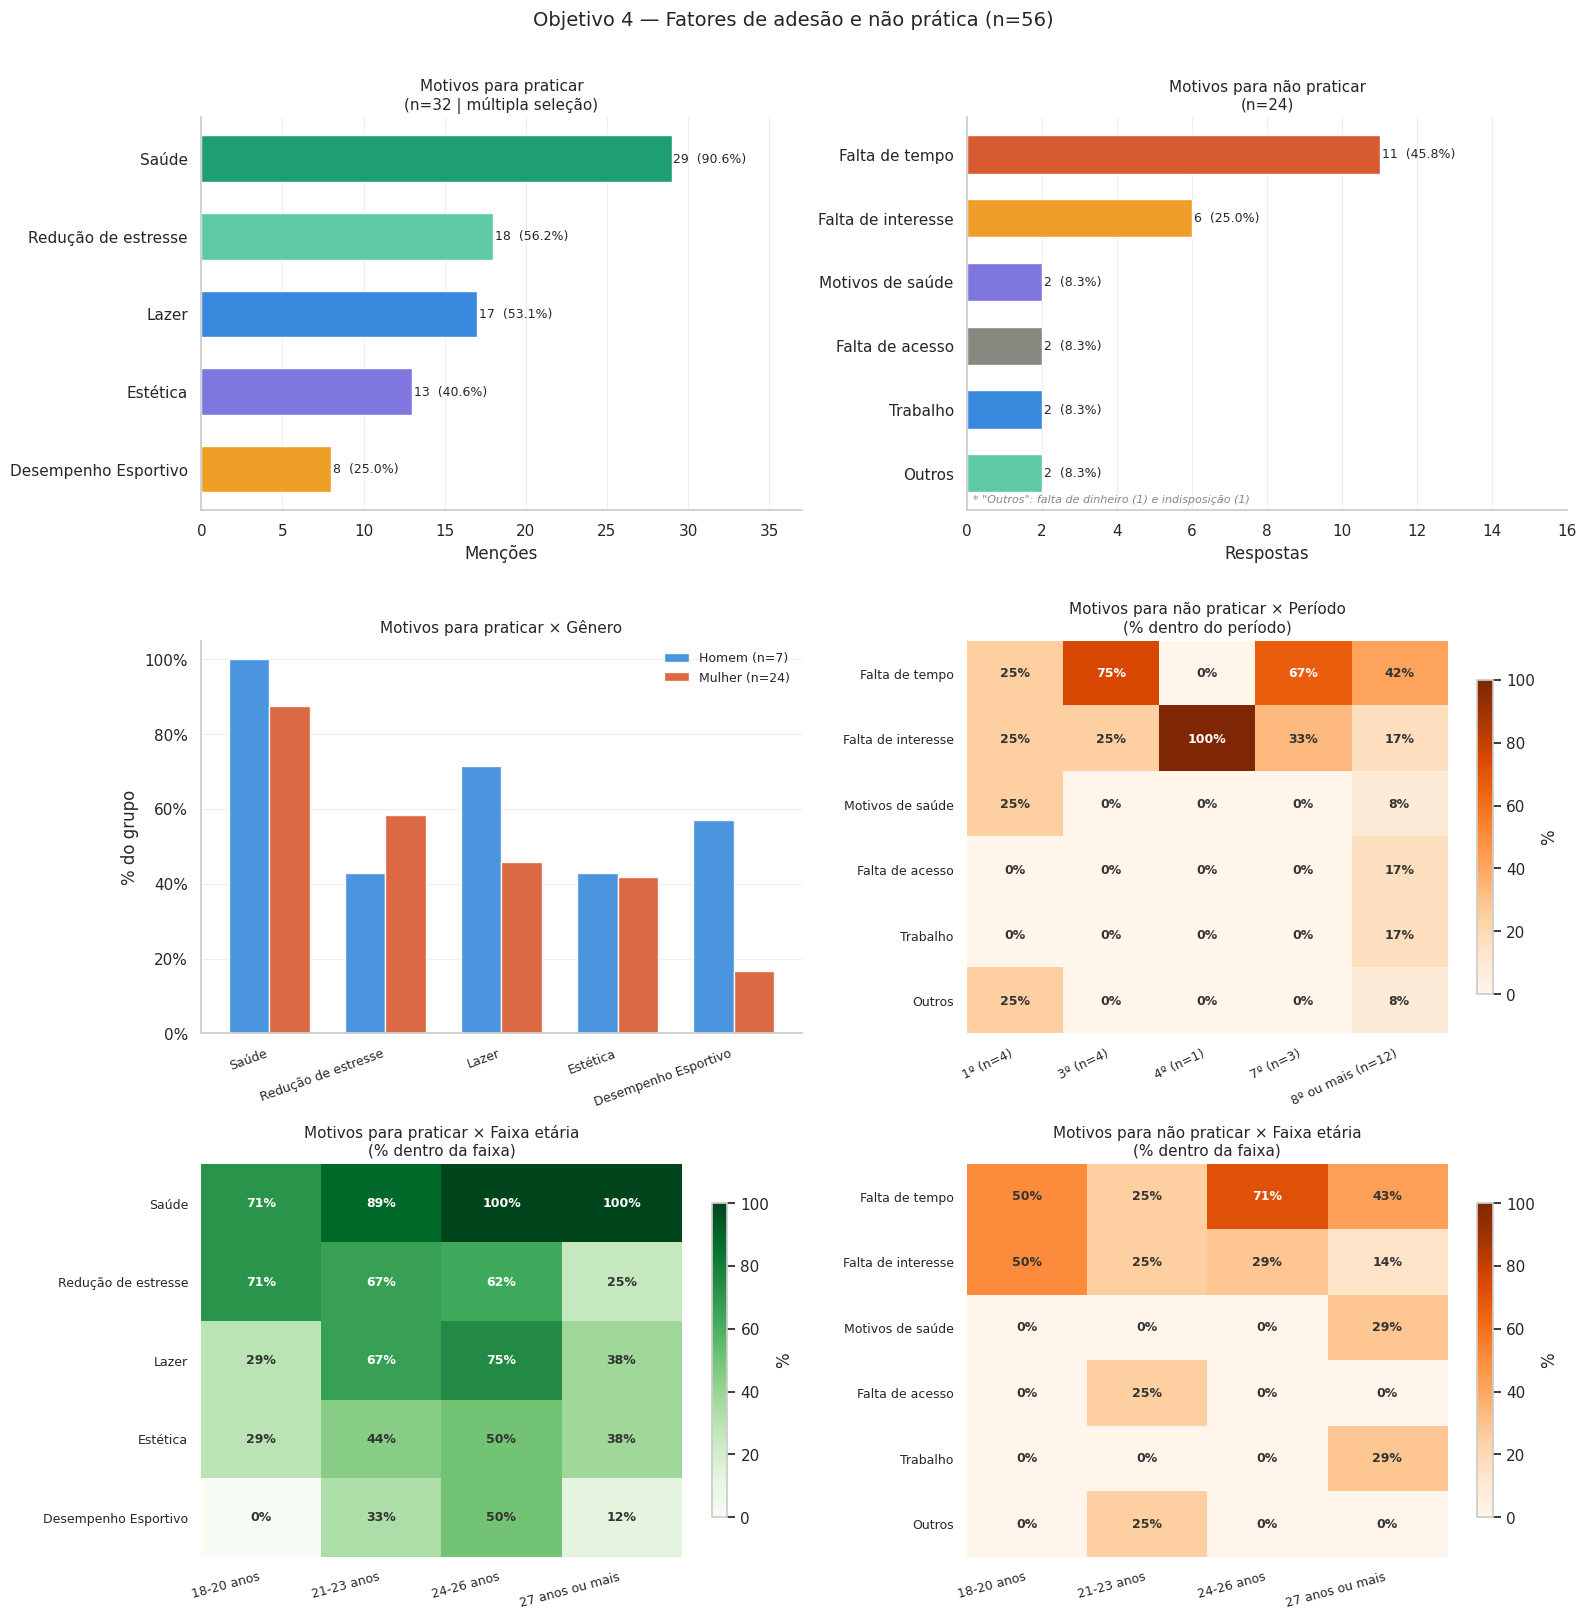

In [ ]:
# ============================================================
# OBJETIVO 4 — Fatores de adesão e não prática
# Pesquisa: Atividade Física entre Universitários — UFSCar São Carlos
# ============================================================
# Investigar os fatores associados à adesão ou à não prática
# de atividades físicas, buscando compreender as principais
# barreiras e motivações relacionadas ao comportamento dos
# universitários.
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from collections import Counter
from matplotlib.patches import Patch

CORES = {
    "azul":   "#378ADD",
    "verde":  "#1D9E75",
    "coral":  "#D85A30",
    "roxo":   "#7F77DD",
    "ambar":  "#EF9F27",
    "cinza":  "#888780",
    "teal":   "#5DCAA5",
}

PALETA_MOT_SIM = [
    CORES["verde"], CORES["teal"], CORES["azul"],
    CORES["roxo"],  CORES["ambar"],
]
PALETA_MOT_NAO = [
    CORES["coral"], CORES["ambar"], CORES["roxo"],
    CORES["cinza"], CORES["azul"],  CORES["teal"],
]

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "white",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.color":        "#eeeeee",
    "grid.linewidth":    0.8,
    "font.family":       "sans-serif",
    "font.size":         11,
})

col_pratica = "Você pratica alguma atividade física regularmente?"
col_genero  = "Como você se identifica em relação ao gênero? "
col_etaria  = "Qual é a sua faixa etária?"
col_periodo = "Em que período do curso você está? "

praticantes    = df_limpo[df_limpo[col_pratica] == "Sim"].copy()
nao_praticantes= df_limpo[df_limpo[col_pratica] == "Não"].copy()
N_sim = len(praticantes)    # 32
N_nao = len(nao_praticantes)# 24

ordem_etaria  = ["18-20 anos","21-23 anos","24-26 anos","27 anos ou mais"]
ordem_periodo = ["1º","2º","3º","4º","5º","6º","7º","8º ou mais"]


# ── CÉLULA 1 — Frequência geral dos motivos ───────────────────
freq_sim = Counter(
    m for lista in praticantes["motivo_sim_lista"].dropna() for m in lista
)
freq_nao = Counter(
    m for lista in nao_praticantes["motivo_nao_lista"].dropna() for m in lista
)

print("=" * 55)
print("OBJETIVO 4 — Fatores de adesão e não prática")
print("=" * 55)

print(f"\nMotivos para PRATICAR (base: {N_sim} praticantes | múltipla seleção):")
for k, v in freq_sim.most_common():
    print(f"  {k:<30} {v:>3}  ({v/N_sim*100:.1f}%)")

print(f"\nMotivos para NÃO PRATICAR (base: {N_nao} não praticantes):")
for k, v in freq_nao.most_common():
    print(f"  {k:<30} {v:>3}  ({v/N_nao*100:.1f}%)")


# ── CÉLULA 2 — Motivos para praticar × Gênero ────────────────
generos = ["Homem", "Mulher"]
tab_mot_sim_gen = {}
for g in generos:
    sub = praticantes[praticantes[col_genero] == g]
    n   = len(sub)
    freq = Counter(m for l in sub["motivo_sim_lista"].dropna() for m in l)
    tab_mot_sim_gen[f"{g} (n={n})"] = {
        k: round(v / n * 100, 1) for k, v in freq.items()
    }

labels_sim = [k for k, _ in freq_sim.most_common()]
df_mot_sim_gen = pd.DataFrame(tab_mot_sim_gen).fillna(0).loc[labels_sim]
print("\nMotivos para praticar × Gênero (% dentro do grupo):")
print(df_mot_sim_gen.round(1).to_string())


# ── CÉLULA 3 — Motivos para praticar × Faixa etária ──────────
tab_mot_sim_eta = {}
for faixa in ordem_etaria:
    sub = praticantes[praticantes[col_etaria] == faixa]
    if len(sub) == 0:
        continue
    n   = len(sub)
    freq = Counter(m for l in sub["motivo_sim_lista"].dropna() for m in l)
    tab_mot_sim_eta[faixa] = {k: round(v / n * 100, 1) for k, v in freq.items()}

df_mot_sim_eta = pd.DataFrame(tab_mot_sim_eta).fillna(0).loc[labels_sim]
print("\nMotivos para praticar × Faixa etária (% dentro do grupo):")
print(df_mot_sim_eta.round(1).to_string())


# ── CÉLULA 4 — Motivos para NÃO praticar × Período ───────────
labels_nao = [k for k, _ in freq_nao.most_common()]
tab_mot_nao_per = {}
for per in ordem_periodo:
    sub = nao_praticantes[nao_praticantes[col_periodo] == per]
    if len(sub) == 0:
        continue
    n   = len(sub)
    freq = Counter(m for l in sub["motivo_nao_lista"].dropna() for m in l)
    tab_mot_nao_per[f"{per} (n={n})"] = {
        k: round(v / n * 100, 1) for k, v in freq.items()
    }

df_mot_nao_per = pd.DataFrame(tab_mot_nao_per).fillna(0).loc[labels_nao]
print("\nMotivos para NÃO praticar × Período (% dentro do grupo):")
print(df_mot_nao_per.round(1).to_string())


# ── CÉLULA 5 — Motivos para NÃO praticar × Faixa etária ──────
tab_mot_nao_eta = {}
for faixa in ordem_etaria:
    sub = nao_praticantes[nao_praticantes[col_etaria] == faixa]
    if len(sub) == 0:
        continue
    n   = len(sub)
    freq = Counter(m for l in sub["motivo_nao_lista"].dropna() for m in l)
    tab_mot_nao_eta[faixa] = {k: round(v / n * 100, 1) for k, v in freq.items()}

df_mot_nao_eta = pd.DataFrame(tab_mot_nao_eta).fillna(0).loc[labels_nao]
print("\nMotivos para NÃO praticar × Faixa etária (% dentro do grupo):")
print(df_mot_nao_eta.round(1).to_string())


# ── CÉLULA 6 — Perfil síntese: praticante vs. não praticante ──
print("\n── Perfil síntese ──")
for grupo, sub, N in [("Praticante", praticantes, N_sim),
                       ("Não praticante", nao_praticantes, N_nao)]:
    gen_modal  = sub[col_genero].value_counts().idxmax()
    eta_modal  = sub[col_etaria].value_counts().idxmax()
    per_modal  = sub[col_periodo].value_counts().idxmax()
    print(f"\n  {grupo} típico (n={N}):")
    print(f"    Gênero mais frequente : {gen_modal}")
    print(f"    Faixa etária modal    : {eta_modal}")
    print(f"    Período modal         : {per_modal}")


# ── CÉLULA 7 — Visualizações ──────────────────────────────────
fig = plt.figure(figsize=(16, 16))
fig.suptitle(
    "Objetivo 4 — Fatores de adesão e não prática (n=56)",
    fontsize=14, y=1.01
)

# --- 4A: Motivos para praticar (geral) ---
ax1 = fig.add_subplot(3, 2, 1)
vals_sim = [freq_sim[k] for k in labels_sim]
pct_sim  = [round(v / N_sim * 100, 1) for v in vals_sim]
bars1 = ax1.barh(labels_sim[::-1], vals_sim[::-1],
                 color=PALETA_MOT_SIM[::-1], height=0.6)
ax1.set_title(f"Motivos para praticar\n(n={N_sim} | múltipla seleção)", fontsize=11)
ax1.set_xlabel("Menções")
for i, (v, p) in enumerate(zip(vals_sim[::-1], pct_sim[::-1])):
    ax1.text(v + 0.1, i, f"{v}  ({p}%)", va="center", fontsize=9)
ax1.set_xlim(0, max(vals_sim) + 8)
ax1.grid(axis="y", visible=False)

# --- 4B: Motivos para NÃO praticar (geral) ---
ax2 = fig.add_subplot(3, 2, 2)
vals_nao = [freq_nao[k] for k in labels_nao]
pct_nao  = [round(v / N_nao * 100, 1) for v in vals_nao]
ax2.barh(labels_nao[::-1], vals_nao[::-1],
         color=PALETA_MOT_NAO[::-1], height=0.6)
ax2.set_title(f"Motivos para não praticar\n(n={N_nao})", fontsize=11)
ax2.set_xlabel("Respostas")
for i, (v, p) in enumerate(zip(vals_nao[::-1], pct_nao[::-1])):
    ax2.text(v + 0.05, i, f"{v}  ({p}%)", va="center", fontsize=9)
ax2.set_xlim(0, max(vals_nao) + 5)
ax2.annotate('* "Outros": falta de dinheiro (1) e indisposição (1)',
             xy=(0.01, 0.02), xycoords="axes fraction",
             fontsize=8, color=CORES["cinza"], style="italic")
ax2.grid(axis="y", visible=False)

# --- 4C: Motivos para praticar × Gênero ---
ax3 = fig.add_subplot(3, 2, 3)
x     = np.arange(len(labels_sim))
width = 0.35
cols_gen = list(df_mot_sim_gen.columns)
ax3.bar(x - width/2, df_mot_sim_gen[cols_gen[0]], width,
        label=cols_gen[0], color=CORES["azul"], alpha=0.9)
ax3.bar(x + width/2, df_mot_sim_gen[cols_gen[1]], width,
        label=cols_gen[1], color=CORES["coral"], alpha=0.9)
ax3.set_xticks(x)
ax3.set_xticklabels(labels_sim, rotation=20, ha="right", fontsize=9)
ax3.set_ylabel("% do grupo")
ax3.set_title("Motivos para praticar × Gênero", fontsize=11)
ax3.yaxis.set_major_formatter(mticker.PercentFormatter())
ax3.legend(frameon=False, fontsize=9)
ax3.grid(axis="x", visible=False)

# --- 4D: Motivos para NÃO praticar × Período (heatmap) ---
ax4 = fig.add_subplot(3, 2, 4)
data_hm = df_mot_nao_per.values
im = ax4.imshow(data_hm, aspect="auto", cmap="Oranges", vmin=0, vmax=100)
ax4.set_xticks(range(len(df_mot_nao_per.columns)))
ax4.set_xticklabels(df_mot_nao_per.columns, fontsize=9, rotation=25, ha="right")
ax4.set_yticks(range(len(labels_nao)))
ax4.set_yticklabels(labels_nao, fontsize=9)
ax4.set_title("Motivos para não praticar × Período\n(% dentro do período)", fontsize=11)
for i in range(data_hm.shape[0]):
    for j in range(data_hm.shape[1]):
        v = data_hm[i, j]
        cor = "white" if v > 55 else "#333"
        ax4.text(j, i, f"{v:.0f}%", ha="center", va="center",
                 fontsize=9, color=cor, fontweight="bold")
plt.colorbar(im, ax=ax4, label="%", shrink=0.8)
ax4.grid(False)
ax4.spines[:].set_visible(False)

# --- 4E: Motivos para praticar × Faixa etária (heatmap) ---
ax5 = fig.add_subplot(3, 2, 5)
data_eta = df_mot_sim_eta.values
im2 = ax5.imshow(data_eta, aspect="auto", cmap="Greens", vmin=0, vmax=100)
ax5.set_xticks(range(len(df_mot_sim_eta.columns)))
ax5.set_xticklabels(df_mot_sim_eta.columns, fontsize=9, rotation=15, ha="right")
ax5.set_yticks(range(len(labels_sim)))
ax5.set_yticklabels(labels_sim, fontsize=9)
ax5.set_title("Motivos para praticar × Faixa etária\n(% dentro da faixa)", fontsize=11)
for i in range(data_eta.shape[0]):
    for j in range(data_eta.shape[1]):
        v = data_eta[i, j]
        cor = "white" if v > 55 else "#333"
        ax5.text(j, i, f"{v:.0f}%", ha="center", va="center",
                 fontsize=9, color=cor, fontweight="bold")
plt.colorbar(im2, ax=ax5, label="%", shrink=0.8)
ax5.grid(False)
ax5.spines[:].set_visible(False)

# --- 4F: Motivos para NÃO praticar × Faixa etária (heatmap) ---
ax6 = fig.add_subplot(3, 2, 6)
data_nao_eta = df_mot_nao_eta.values
im3 = ax6.imshow(data_nao_eta, aspect="auto", cmap="Oranges", vmin=0, vmax=100)
ax6.set_xticks(range(len(df_mot_nao_eta.columns)))
ax6.set_xticklabels(df_mot_nao_eta.columns, fontsize=9, rotation=15, ha="right")
ax6.set_yticks(range(len(labels_nao)))
ax6.set_yticklabels(labels_nao, fontsize=9)
ax6.set_title("Motivos para não praticar × Faixa etária\n(% dentro da faixa)", fontsize=11)
for i in range(data_nao_eta.shape[0]):
    for j in range(data_nao_eta.shape[1]):
        v = data_nao_eta[i, j]
        cor = "white" if v > 55 else "#333"
        ax6.text(j, i, f"{v:.0f}%", ha="center", va="center",
                 fontsize=9, color=cor, fontweight="bold")
plt.colorbar(im3, ax=ax6, label="%", shrink=0.8)
ax6.grid(False)
ax6.spines[:].set_visible(False)

plt.tight_layout()
plt.savefig("plot_objetivo4.png", dpi=150, bbox_inches="tight")
plt.show()


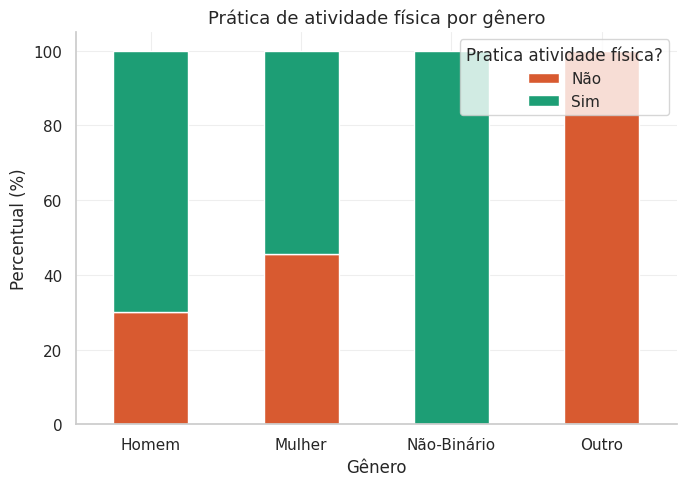

In [ ]:
# ============================================================
# NÃO PRÁTICA DE ATIVIDADE FÍSICA POR GÊNERO
# (proporção dentro de cada gênero)
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

col_pratica = "Você pratica alguma atividade física regularmente?"
col_genero  = "Como você se identifica em relação ao gênero? "

# ============================================================
# TABELA PROPORCIONAL
# ============================================================

tabela = pd.crosstab(
    df_limpo[col_genero],
    df_limpo[col_pratica],
    normalize='index'
) * 100

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(7,5))

tabela.plot(
    kind='bar',
    stacked=True,
    color=["#D85A30", "#1D9E75"],  # Não / Sim
    ax=ax
)

ax.set_title(
    "Prática de atividade física por gênero",
    fontsize=13
)

ax.set_ylabel("Percentual (%)")
ax.set_xlabel("Gênero")

ax.legend(
    title="Pratica atividade física?",
    labels=["Não", "Sim"]
)

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig(
    "plot_pratica_genero_proporcional.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Categorias (pratica):
['Desempenho Esportivo', 'Estética', 'Lazer', 'Redução de estresse', 'Saúde']


/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

<Figure size 1200x600 with 0 Axes>

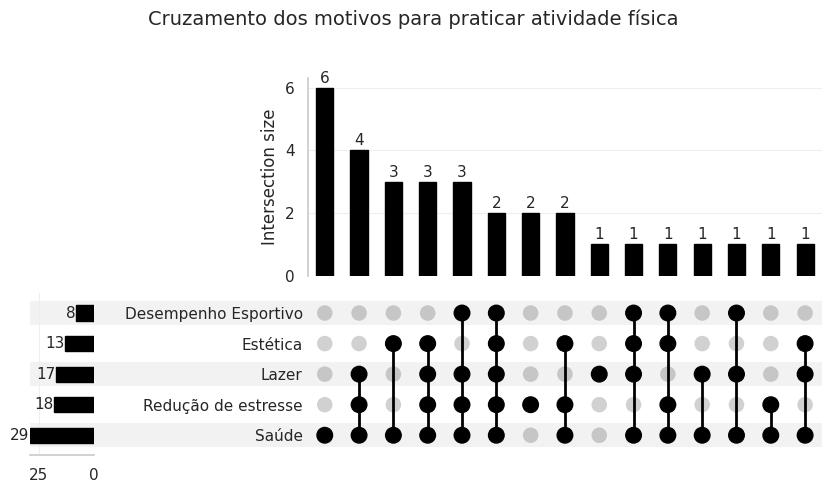


Categorias (não pratica):
['Falta de acesso', 'Falta de interesse', 'Falta de tempo', 'Motivos de saúde', 'Outros', 'Trabalho']


/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

<Figure size 1000x500 with 0 Axes>

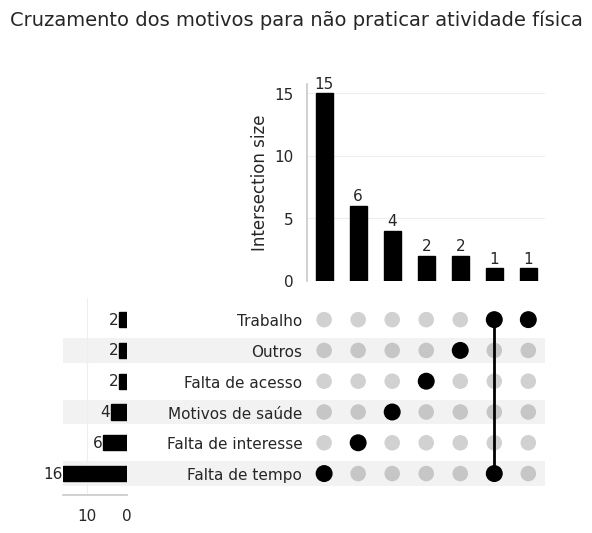

In [ ]:
# ============================================================
# GRÁFICOS UPSET — CRUZAMENTO DE RESPOSTAS
# Motivos para praticar / não praticar atividade física
# ============================================================

# Instalar biblioteca (execute uma vez no Colab)
!pip install upsetplot -q

import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_indicators

# ============================================================
# 1 — MOTIVOS PARA PRATICAR
# ============================================================

# Remove nulos
df_pratica = df_limpo[df_limpo["motivo_sim_lista"].notna()].copy()

# Descobrir todas as categorias existentes
categorias_pratica = sorted({
    item
    for lista in df_pratica["motivo_sim_lista"]
    for item in lista
})

print("Categorias (pratica):")
print(categorias_pratica)

# Criar colunas booleanas
for cat in categorias_pratica:
    df_pratica[cat] = df_pratica["motivo_sim_lista"].apply(
        lambda x: cat in x if isinstance(x, list) else False
    )

# Converter para formato upset
upset_data_pratica = from_indicators(
    categorias_pratica,
    df_pratica[categorias_pratica]
)

# Plot
plt.figure(figsize=(12, 6))

upset = UpSet(
    upset_data_pratica,
    subset_size='count',
    show_counts=True,
    sort_by='cardinality',
    min_subset_size=1
)

upset.plot()

plt.suptitle(
    "Cruzamento dos motivos para praticar atividade física",
    fontsize=14,
    y=1.02
)

plt.show()


# ============================================================
# 2 — MOTIVOS PARA NÃO PRATICAR
# ============================================================

df_nao = df_limpo[df_limpo["motivo_nao_lista"].notna()].copy()

categorias_nao = sorted({
    item
    for lista in df_nao["motivo_nao_lista"]
    for item in lista
})

print("\nCategorias (não pratica):")
print(categorias_nao)

# Criar colunas booleanas
for cat in categorias_nao:
    df_nao[cat] = df_nao["motivo_nao_lista"].apply(
        lambda x: cat in x if isinstance(x, list) else False
    )

# Converter para formato upset
upset_data_nao = from_indicators(
    categorias_nao,
    df_nao[categorias_nao]
)

# Plot
plt.figure(figsize=(10, 5))

upset2 = UpSet(
    upset_data_nao,
    subset_size='count',
    show_counts=True,
    sort_by='cardinality',
    min_subset_size=1
)

upset2.plot()

plt.suptitle(
    "Cruzamento dos motivos para não praticar atividade física",
    fontsize=14,
    y=1.02
)

plt.show()

/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  styles["linewidth"].fillna(1, inplace=True)
/usr/local/lib/python3.12/dist-packages/upsetplot/plotting.py:796: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

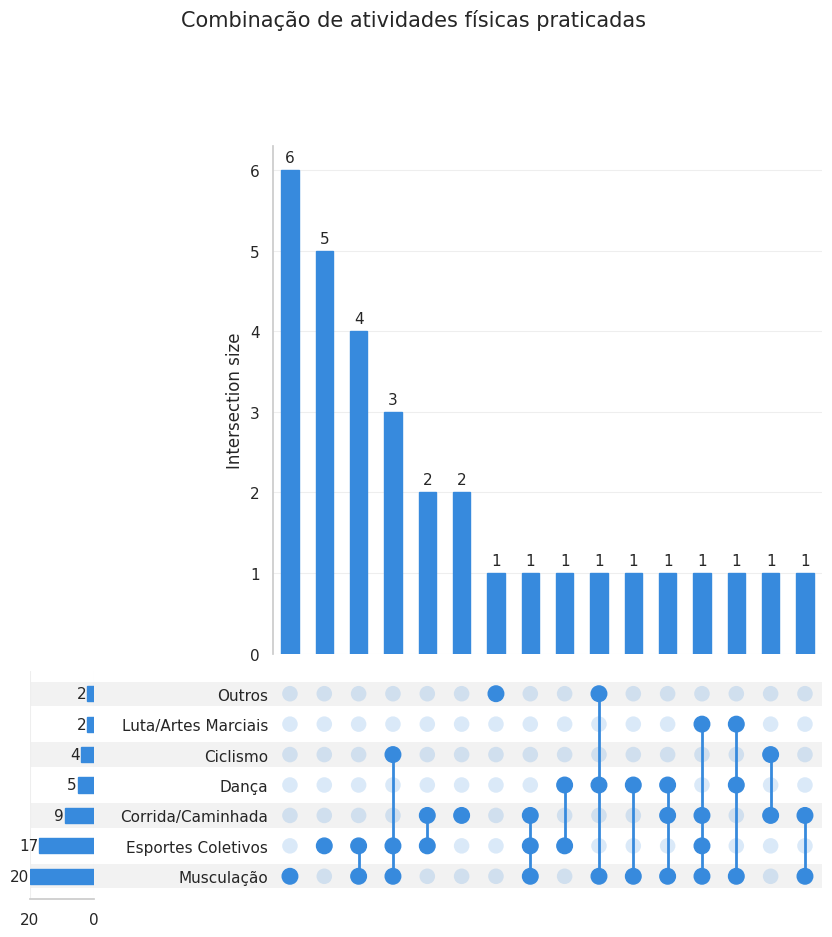

In [ ]:
# ============================================================
# UPSET PLOT ESTILIZADO — ATIVIDADES PRATICADAS
# ============================================================

!pip install upsetplot -q

import pandas as pd
import matplotlib.pyplot as plt
from upsetplot import UpSet, from_indicators

# ============================================================
# DADOS
# ============================================================

df_up = df_limpo[df_limpo["atividade_lista"].notna()].copy()

categorias = [
    "Musculação",
    "Esportes Coletivos",
    "Corrida/Caminhada",
    "Dança",
    "Ciclismo",
    "Luta/Artes Marciais",
    "Outros"
]

# Criar colunas booleanas
for cat in categorias:
    df_up[cat] = df_up["atividade_lista"].apply(
        lambda x: cat in x if isinstance(x, list) else False
    )

# Converter formato
upset_data = from_indicators(
    categorias,
    df_up[categorias]
)

# ============================================================
# PLOT
# ============================================================

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "font.size": 11,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

fig = plt.figure(figsize=(13, 6))

upset = UpSet(
    upset_data,

    # estilo
    subset_size='count',
    show_counts=True,
    sort_by='cardinality',

    # aparência semelhante à imagem
    facecolor="#378ADD",
    shading_color="#f2f2f2",

    # mostrar tudo
    min_subset_size=1,

    # tamanho barras laterais
    intersection_plot_elements=15
)

upset.plot(fig=fig)

plt.suptitle(
    "Combinação de atividades físicas praticadas",
    fontsize=15,
    y=1.02
)

plt.show()

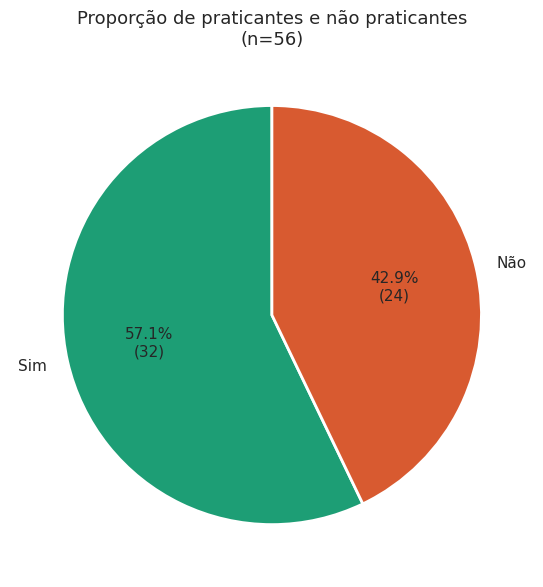

In [ ]:
# ── PROPORÇÃO DE PRATICANTES E NÃO PRATICANTES ───────────────

col_pratica = "Você pratica alguma atividade física regularmente?"

# Contagem
vc_pratica = df_limpo[col_pratica].value_counts()

# Percentuais
percentuais = (vc_pratica / vc_pratica.sum()) * 100

# ============================================================
# PLOT
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

cores = ["#1D9E75", "#D85A30"]  # verde / coral

wedges, texts, autotexts = ax.pie(
    vc_pratica.values,
    labels=vc_pratica.index,
    autopct=lambda p: f"{p:.1f}%\n({round(p*vc_pratica.sum()/100):.0f})",
    startangle=90,
    colors=cores,
    wedgeprops=dict(edgecolor="white", linewidth=2),
    textprops=dict(fontsize=11)
)

ax.set_title(
    "Proporção de praticantes e não praticantes\n(n=56)",
    fontsize=13
)

plt.tight_layout()
plt.savefig(
    "plot_proporcao_pratica.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()